# 25일 랜드마크 코호트 EDA (`03_Landmark25_EDA`)

## 이 노트북의 위치와 목적

```
01_Window_Definition → 02_Integrated_Table → [03_Landmark25_EDA] → 04_Missing_Outlier → 05_Collinearity_Recheck → 03_Modeling
```

`02_Integrated_Table`이 만든 25일 코호트(`landmark25_all_cohorts.csv`)를 **전처리 결정 전에** 탐색한다.
기존 EDA(`01_EDA_Basic`)는 원본 테이블 단위였고, 관측창 분석(`01_Window_Definition`)은 이탈자 전체의
신호 비교였다. **"25일 시점 재학생 + 25일까지의 피처"라는 실제 모델 입력 단위로 분포·타깃 관계를 본
단계가 없었고**, 그 공백 때문에 다음 문제가 모델링 이후에야 드러났다
(`work_process/reports/07_pipeline_audit_before_final.md`).

- 과목·학기마다 평가 일정이 달라 같은 피처가 다른 의미가 됨 (BBB 2014J)
- 이월 재수강생이 "전부 미제출"로 기록됨
- 과목마다 기준 이탈률과 활동량 규모가 크게 다름 (GGG)

이 노트북은 그 발견을 **재현 가능한 표와 그래프로 고정**하고, 이후 단계(04 결측·이상치, 05 공선성,
모델링)가 무엇을 반영해야 하는지 근거를 남긴다.

## 원칙

- **읽기 전용**: 데이터를 수정·저장하지 않는다. 처리 결정은 04·05 노트북과 결정 문서가 맡는다.
- **과목(모듈)을 중심 축으로 본다**: 전체 평균만 보면 과목 간 구조 차이가 가려진다.
- **학기 비교는 분포 확인용이다**: `2014J`는 모델링의 최종 holdout이다. 여기서는 피처 분포와 구조
  변화만 확인하고, **2014J 성과를 보고 피처·임계값을 고르지 않는다**(모델링에서 개발 세트로만 결정).
- 각 절은 **왜 보는가 → 코드 → 해석 → 다음 단계 반영** 순서로 쓴다.

## 선행 문서

- `work_process/decisions/target_definition/0829_01_landmark_prediction_target.md` (예측 문제)
- `work_process/decisions/modeling/0902_01_landmark_n25_final.md` (N=25)
- `work_process/decisions/preprocessing/0913_01_assessment_opportunity_banked.md` (평가 기회·이월 정의 변경)
- `docs/데이터_사전.md` 8번 절 (컬럼 정의), "과목(모듈) 분야" 절 (분야 출처)

## 1. 환경 설정과 데이터 로드

**왜 보는가**: 이후 모든 절이 같은 데이터·색상·서식을 쓰도록 한 곳에서 정한다.

- 입력: 통합 정본 `landmark25_all_cohorts.csv`(전체 코호트), 평가 일정 구조 확인용 원본 `assessments.csv`
- 색상: 과목 7개는 고정 순서의 범주형 팔레트(색각 이상 대비 검증 통과), 잔류/이탈은 파랑/주황으로
  모든 그래프에서 같게 쓴다. 대비가 낮은 색이 있어 **값 라벨이나 표를 그래프와 함께** 둔다.
- 비율 히트맵은 단일 색상(파랑) 명도 단계로 표현한다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from sklearn.metrics import roc_auc_score

INK, INK_2, MUTED, GRID, AXIS, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7', '#fcfcfb'
plt.rcParams.update({
    'font.family': 'Malgun Gothic',
    'axes.unicode_minus': False,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': AXIS,
    'axes.labelcolor': INK_2,
    'axes.titlecolor': INK,
    'axes.titlesize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'text.color': INK_2,
    'legend.frameon': False,
    'lines.linewidth': 2,
})
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'CSV_files').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '../..').resolve()
CSV_DIR = PROJECT_ROOT / 'CSV_files'

all_cohorts = pd.read_csv(CSV_DIR / '통합 버전' / 'landmark25_all_cohorts.csv')
assessments = pd.read_csv(CSV_DIR / 'assessments.csv')

TARGET = 'target_churn_after_25'
KEYS = ['code_module', 'code_presentation', 'id_student']
MODULES = ['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG']
TERMS = ['2013B', '2013J', '2014B', '2014J']
# 분야: Kuzilek et al. (2017), Scientific Data 4:170171, Table 1
DOMAIN = {'AAA': '사회', 'BBB': '사회', 'GGG': '사회', 'CCC': 'STEM', 'DDD': 'STEM', 'EEE': 'STEM', 'FFF': 'STEM'}
MODULE_COLORS = dict(zip(MODULES, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7']))
C_STAY, C_CHURN = '#2a78d6', '#eb6834'
SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#cde2fb', '#86b6ef', '#3987e5', '#1c5cab', '#0d366b'])


def show(frame, formats=None):
    # jinja2 없이 열별 서식을 적용해 표시한다
    view = frame.copy()
    for col, f in (formats or {}).items():
        if col in view.columns:
            view[col] = view[col].map(lambda v, f=f: f.format(v) if pd.notna(v) else '')
    display(view)


def heatmap(pivot, ax, fmt='{:.1%}', title='', vmin=None, vmax=None, counts=None, min_n=30):
    # 값 라벨이 있는 단일 색상 히트맵. counts가 주어지면 표본이 min_n 미만인 칸은 흐리게 표시
    data = pivot.to_numpy(dtype=float)
    im = ax.imshow(np.ma.masked_invalid(data), cmap=SEQ, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(pivot.shape[1]), [str(c) for c in pivot.columns])
    ax.set_yticks(range(pivot.shape[0]), [str(i) for i in pivot.index])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    lo, hi = np.nanmin(data), np.nanmax(data)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if np.isnan(v):
                ax.text(j, i, '—', ha='center', va='center', color=MUTED, fontsize=9)
                continue
            dark = (v - lo) / (hi - lo + 1e-12) > 0.55
            label = fmt.format(v)
            if counts is not None:
                n = counts.iloc[i, j]
                label += f'\nn={int(n):,}'
                if n < min_n:
                    label += '*'
            ax.text(j, i, label, ha='center', va='center', fontsize=8.5,
                    color='#ffffff' if dark else INK)
    ax.set_title(title, loc='left')
    return im


model_df = all_cohorts[all_cohorts['cohort_status_25'] == 'model_eligible'].copy()
model_df[TARGET] = model_df[TARGET].astype(int)
model_df['domain'] = model_df['code_module'].map(DOMAIN)

# 02 노트북 산출물 계약 재확인 — 이 노트북이 전제하는 입력이 맞는지
assert len(all_cohorts) == 32_593
assert len(model_df) == 27_661 and model_df[TARGET].sum() == 5_247
assert not model_df.duplicated(KEYS).any()
assert 'n_banked_25' in model_df.columns, '평가 기회·이월 정의 변경(0913_01)이 반영되지 않은 통합 정본'
assert (model_df['n_submitted_25'] <= model_df['n_opportunity_25']).all()

print('전체 코호트:', all_cohorts.shape, '/ 모델 대상:', model_df.shape)
print(f'이탈률: {model_df[TARGET].mean():.2%}')

전체 코호트: (32593, 30) / 모델 대상: (27661, 31)
이탈률: 18.97%


## 2. 코호트 흐름 — 25일 모델이 다룰 수 있는 이탈의 범위

**왜 보는가**: 25일 랜드마크 모델은 "25일에 아직 남아 있는 학생"만 예측한다. 전체 이탈 중 **25일 전에
이미 떠난 이탈은 이 모델의 대상이 아니다.** 그 비율이 과목마다 다르면, 과목별 이탈률·모델 성능을
해석할 때 "남은 학생이 어떤 집단인가"가 달라진다.

**무엇을 보는가**

- 전체 등록 32,593행이 네 세그먼트로 어떻게 나뉘는지
- 과목별로 "25일 전 이탈 / 25일 후 이탈 / 잔류(Pass·Distinction·Fail) / 기타 제외" 구성비
- 전체 `Withdrawn` 중 25일 전에 떠난 비율

,행 수,비율
cohort_status_25,,
모델 대상,"27,661",84.9%
제외: 25일까지 이탈,"4,819",14.8%
제외: 판정 불명(취소일 없음),93,0.3%
제외: 25일 이후 등록,20,0.1%


구분,25일까지 이탈,25일 후 이탈,잔류(Pass·Dist·Fail),기타 제외,전체 Withdrawn 중 25일까지 이탈,등록 행 수
code_module,,,,,,
AAA,3.9%,13.0%,83.0%,0.1%,23.0%,748
BBB,17.8%,12.3%,69.7%,0.3%,58.8%,"7,909"
CCC,19.8%,24.1%,55.5%,0.7%,44.4%,"4,434"
DDD,14.9%,20.7%,64.0%,0.4%,41.4%,"6,272"
EEE,12.8%,11.7%,75.4%,0.2%,51.9%,"2,934"
FFF,14.2%,16.4%,69.0%,0.4%,45.8%,"7,762"
GGG,3.7%,7.7%,88.5%,0.1%,32.5%,"2,534"


전체 Withdrawn 10,156건 중 25일까지 이탈: 47.4%


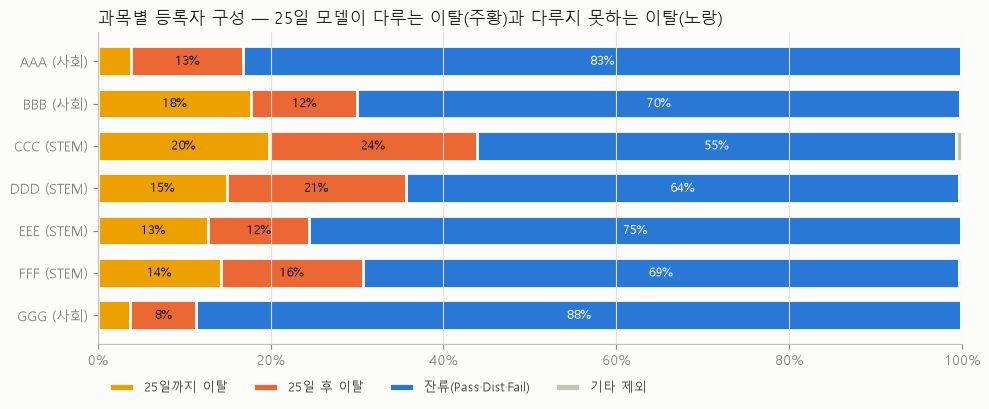

In [2]:
status_label = {
    'model_eligible': '모델 대상',
    'excluded_early_leaver': '제외: 25일까지 이탈',
    'excluded_ambiguous_withdrawn': '제외: 판정 불명(취소일 없음)',
    'excluded_late_registration': '제외: 25일 이후 등록',
}
flow = all_cohorts['cohort_status_25'].map(status_label).value_counts().rename('행 수').to_frame()
flow['비율'] = flow['행 수'] / len(all_cohorts)
show(flow, {'행 수': '{:,}', '비율': '{:.1%}'})

ac = all_cohorts.copy()
ac['구분'] = np.select(
    [
        ac['cohort_status_25'] == 'excluded_early_leaver',
        (ac['cohort_status_25'] == 'model_eligible') & (ac[TARGET] == 1),
        ac['cohort_status_25'] == 'model_eligible',
    ],
    ['25일까지 이탈', '25일 후 이탈', '잔류(Pass·Dist·Fail)'],
    default='기타 제외',
)
order = ['25일까지 이탈', '25일 후 이탈', '잔류(Pass·Dist·Fail)', '기타 제외']
comp = pd.crosstab(ac['code_module'], ac['구분'], normalize='index').reindex(columns=order).reindex(MODULES)
comp_n = pd.crosstab(ac['code_module'], ac['구분']).reindex(columns=order).reindex(MODULES)

withdrawn = ac[ac['final_result'] == 'Withdrawn']
early_of_withdrawn = (withdrawn['cohort_status_25'] == 'excluded_early_leaver').groupby(withdrawn['code_module']).mean()
comp_table = comp.copy()
comp_table['전체 Withdrawn 중 25일까지 이탈'] = early_of_withdrawn
comp_table['등록 행 수'] = comp_n.sum(axis=1)
show(comp_table, {c: '{:.1%}' for c in order + ['전체 Withdrawn 중 25일까지 이탈']} | {'등록 행 수': '{:,}'})
print(f'전체 Withdrawn {len(withdrawn):,}건 중 25일까지 이탈: '
      f'{(withdrawn["cohort_status_25"] == "excluded_early_leaver").mean():.1%}')

fig, ax = plt.subplots(figsize=(10, 4.2))
seg_colors = ['#eda100', C_CHURN, C_STAY, '#c3c2b7']
left = np.zeros(len(MODULES))
for col, color in zip(order, seg_colors):
    vals = comp[col].to_numpy()
    ax.barh(MODULES, vals, left=left, color=color, edgecolor=SURFACE, linewidth=2, label=col, height=0.7)
    for k, v in enumerate(vals):
        if v >= 0.07:
            ax.text(left[k] + v / 2, k, f'{v:.0%}', ha='center', va='center', fontsize=8.5,
                    color='#ffffff' if color in (C_STAY,) else INK)
    left += vals
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_yticks(range(len(MODULES)), [f'{m} ({DOMAIN[m]})' for m in MODULES])
ax.grid(axis='y', visible=False)
ax.set_title('과목별 등록자 구성 — 25일 모델이 다루는 이탈(주황)과 다루지 못하는 이탈(노랑)', loc='left')
ax.legend(ncol=4, loc='upper left', bbox_to_anchor=(0, -0.08), fontsize=9)
plt.tight_layout()
plt.show()

**해석**

- 전체 등록 32,593행 중 **모델 대상은 84.9%**, 25일까지 이미 이탈해 제외된 행이 14.8%다.
- **전체 `Withdrawn` 10,156건 중 47.4%가 25일 전에 떠났다.** 25일 랜드마크 모델은 이탈의 약 절반만
  다룬다. 이 모델의 성과는 "전체 이탈 예측"이 아니라 **"25일에 남아 있는 학생 중 이후 이탈 예측"**으로
  보고해야 한다.
- 과목별 편차가 크다. **BBB는 이탈의 58.8%가 25일 전에 발생**해 25일 모델이 다룰 수 있는 이탈이
  절반에 못 미친다. 반대로 AAA(23.0%)·GGG(32.5%)는 대부분의 이탈이 25일 이후에 일어난다.
- 25일까지 이탈 비율이 높은 과목(CCC 19.8%, BBB 17.8%)은 모델 대상이 "초기 고비를 넘긴 학생" 쪽으로
  더 걸러진 집단이다.

**다음 단계 반영**

- 최종 보고(P6)에 모수("25일 재학생")와 **다루지 못하는 초기 이탈 47.4%**를 한계로 명시한다.
- BBB처럼 초기 이탈이 많은 과목은 25일보다 이른 개입이 별도 과제일 수 있다(P5 개입 전략에서 언급).

## 3. 타깃 분포 — 과목 × 학기 이탈률

**왜 보는가**: 모델은 전체 이탈률 약 19%를 기준으로 학습하지만, 실제 기준 이탈률은 과목·학기마다 다를
수 있다. 과목 간 차이가 크면 `code_module`이 강한 피처가 되고, **같은 과목 안에서 학기마다 이탈률이
움직이면** 과거 학기로 학습한 모델이 새 학기의 확률 수준을 틀리게 된다(보정·임계값 문제).

**무엇을 보는가**: 과목 × 학기 이탈률과 표본 수. 과목이 개설되지 않은 학기는 `—`.

,행_수,이탈_수,이탈률,학기별 이탈률 범위(최대-최소),개설 학기 수
code_module,,,,,
AAA,718,97,13.5%,1.1%p,2
BBB,"6,483",971,15.0%,8.4%p,4
CCC,"3,527","1,068",30.3%,2.5%p,2
DDD,"5,314","1,299",24.4%,8.4%p,4
EEE,"2,554",343,13.4%,1.4%p,3
FFF,"6,629","1,275",19.2%,2.4%p,4
GGG,"2,436",194,8.0%,8.9%p,3


,행 수,이탈률
code_presentation,,
2013B,"4,278",22.1%
2013J,"7,693",16.0%
2014B,"6,539",20.7%
2014J,"9,151",18.8%


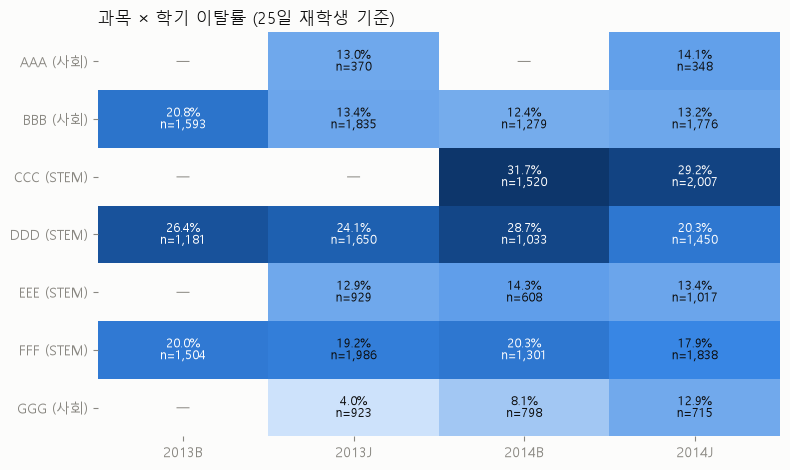

In [3]:
churn_mt = model_df.pivot_table(index='code_module', columns='code_presentation', values=TARGET, aggfunc='mean').reindex(index=MODULES, columns=TERMS)
n_mt = model_df.pivot_table(index='code_module', columns='code_presentation', values=TARGET, aggfunc='size').reindex(index=MODULES, columns=TERMS)

summary = model_df.groupby('code_module').agg(행_수=(TARGET, 'size'), 이탈_수=(TARGET, 'sum'), 이탈률=(TARGET, 'mean')).reindex(MODULES)
summary['학기별 이탈률 범위(최대-최소)'] = churn_mt.max(axis=1) - churn_mt.min(axis=1)
summary['개설 학기 수'] = n_mt.notna().sum(axis=1)
show(summary, {'행_수': '{:,}', '이탈_수': '{:,}', '이탈률': '{:.1%}', '학기별 이탈률 범위(최대-최소)': '{:.1%}p'})

term_rate = model_df.groupby('code_presentation')[TARGET].agg(['size', 'mean']).reindex(TERMS)
show(term_rate.rename(columns={'size': '행 수', 'mean': '이탈률'}), {'행 수': '{:,}', '이탈률': '{:.1%}'})

fig, ax = plt.subplots(figsize=(8, 4.8))
heatmap(churn_mt, ax, counts=n_mt, title='과목 × 학기 이탈률 (25일 재학생 기준)')
ax.set_yticks(range(len(MODULES)), [f'{m} ({DOMAIN[m]})' for m in MODULES])
plt.tight_layout()
plt.show()

**해석**

- **과목 간 기준 이탈률이 8.0%(GGG)에서 30.3%(CCC)까지 약 3.8배 차이**난다. `code_module`만으로도
  위험 수준을 상당 부분 가를 수 있다는 뜻이다.
- **같은 과목 안에서 학기마다 이탈률이 크게 움직이는 과목이 세 개**다.
  - GGG: 4.0% → 8.1% → 12.9%로 **학기마다 상승**(범위 8.9%p)
  - BBB: 2013B 20.8% → 이후 12.4–13.4% (범위 8.4%p)
  - DDD: 2014B 28.7% → 2014J 20.3% (범위 8.4%p)
  - AAA·CCC·EEE·FFF는 범위 2.5%p 이내로 안정적이다.
- 학기 전체로는 두 해 모두 B학기가 J학기보다 높다(2013B 22.1% > 2013J 16.0%, 2014B 20.7% > 2014J 18.8%).
  `presentation_period`(B/J) 파생의 근거(`0912_03` 결정 문서 6절)와 일치한다.

**다음 단계 반영**

- 과거 학기로 학습한 모델은 GGG처럼 기준 이탈률이 오르는 과목에서 **확률을 낮게 잡는다.** 모델링에서
  (1) 학기 단위 검증, (2) 확률 보정, (3) **과목별 성능표**를 기본으로 보고한다.

## 4. 과목 프로파일 — 과목마다 무엇이 다른가

**왜 보는가**: 과목 간 차이가 이탈률에만 있는지, 학습 활동 규모·평가 구조·학생 구성까지 다른지 확인한다.
활동 규모가 과목마다 다르면 "클릭 100회"의 의미가 과목마다 달라지고, 학생 구성(예: 성비)이 과목에
묶여 있으면 인구통계 피처의 효과가 과목 효과와 섞인다.

**분야 출처**: 데이터에는 분야 컬럼이 없다. 사회과학/STEM 구분은 원 논문 Table 1을 따른다
(Kuzilek, Hlosta & Zdrahal, 2017, *Scientific Data* 4:170171, https://doi.org/10.1038/sdata.2017.171).
실제 과목명·난이도는 공개되지 않으므로 **과목의 성격은 이 절처럼 데이터로 확인**한다.

,분야,행_수,이탈률,클릭_중앙값,활동일_중앙값,자원수_중앙값,무활동_비율,평균_평가기회,재수강_비율,여성_비율,학점_중앙값
code_module,,,,,,,,,,,
AAA,사회,718,13.5%,262,13,20,0.4%,0.98,5.3%,40.8%,60
BBB,사회,"6,483",15.0%,88,6,13,6.6%,0.99,15.3%,88.3%,60
CCC,STEM,"3,527",30.3%,196,9,17,2.4%,0.99,5.6%,24.2%,60
DDD,STEM,"5,314",24.4%,155,11,25,3.0%,1.19,18.8%,39.6%,60
EEE,STEM,"2,554",13.4%,268,10,16,3.7%,0.00,4.9%,11.2%,60
FFF,STEM,"6,629",19.2%,371,13,37,2.6%,0.98,15.9%,18.0%,60
GGG,사회,"2,436",8.0%,31,3,7,15.1%,0.00,3.3%,80.8%,30


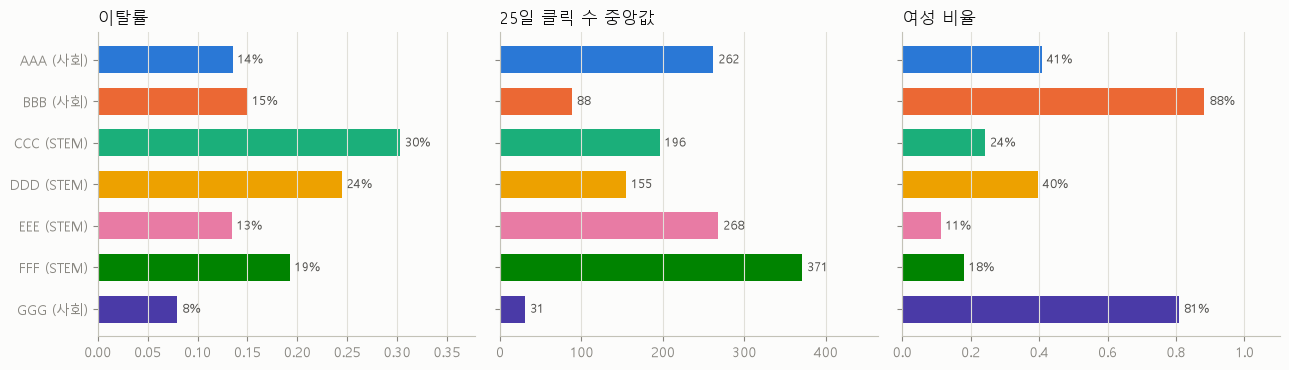

In [4]:
profile = model_df.groupby('code_module').agg(
    분야=('domain', 'first'),
    행_수=(TARGET, 'size'),
    이탈률=(TARGET, 'mean'),
    클릭_중앙값=('total_click_25', 'median'),
    활동일_중앙값=('active_days_25', 'median'),
    자원수_중앙값=('distinct_resources_25', 'median'),
    무활동_비율=('no_vle_activity_25', 'mean'),
    평균_평가기회=('n_opportunity_25', 'mean'),
    재수강_비율=('num_of_prev_attempts', lambda s: (s > 0).mean()),
    여성_비율=('gender', lambda s: (s == 'F').mean()),
    학점_중앙값=('studied_credits', 'median'),
).reindex(MODULES)
show(profile, {'행_수': '{:,}', '이탈률': '{:.1%}', '무활동_비율': '{:.1%}', '평균_평가기회': '{:.2f}',
               '재수강_비율': '{:.1%}', '여성_비율': '{:.1%}', '클릭_중앙값': '{:.0f}', '활동일_중앙값': '{:.0f}',
               '자원수_중앙값': '{:.0f}', '학점_중앙값': '{:.0f}'})

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
labels = [f'{m} ({DOMAIN[m]})' for m in MODULES]
for ax, (col, title, fmt) in zip(axes, [
    ('이탈률', '이탈률', '{:.0%}'),
    ('클릭_중앙값', '25일 클릭 수 중앙값', '{:.0f}'),
    ('여성_비율', '여성 비율', '{:.0%}'),
]):
    vals = profile[col].to_numpy(dtype=float)
    ax.barh(labels, vals, color=[MODULE_COLORS[m] for m in MODULES], height=0.65)
    for k, v in enumerate(vals):
        ax.text(v, k, ' ' + fmt.format(v), va='center', fontsize=9, color=INK_2)
    ax.set_title(title, loc='left')
    ax.grid(axis='y', visible=False)
    ax.set_xlim(0, vals.max() * 1.25)
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()

**해석**

- **활동 규모가 과목마다 다르다.** 25일 클릭 중앙값은 GGG 31회에서 FFF 371회까지 약 12배, 활동일 중앙값은
  3일(GGG)에서 13일(AAA·FFF)까지 차이난다. GGG는 25일간 활동이 전혀 없는 학생도 15.1%다.
- **이탈률과 활동량의 과목 순서가 다르다.** GGG는 활동이 가장 적은데 이탈률도 가장 낮고, CCC는 이탈률이
  가장 높지만 클릭은 중간(196회)이다. **절대 활동량으로는 과목 간 위험을 비교할 수 없다**(8절에서 확인).
- **평가 구조가 다르다.** EEE·GGG는 25일 안에 마감되는 평가가 없어(평균 기회 0.00) 평가 피처로 학생을
  구분할 수 없다. DDD는 평균 1.19회로 한 학기(2013B)만 2회다(5절).
- **학생 구성이 과목에 묶여 있다.** 여성 비율이 EEE 11.2%에서 BBB 88.3%까지 갈린다. 성별 피처의 효과가
  과목 효과와 섞일 수 있다(10절). GGG는 학점 중앙값도 30으로 다른 과목(60)의 절반이다.

**다음 단계 반영**: 과목 내 상대 활동량 피처 비교(8절 → 모델링), 성별 해석 주의(10절 → P5).

## 5. 과목 × 학기 평가 일정 구조

**왜 보는가**: 평가 피처(`n_opportunity_25`, `n_submitted_25`, `avg_score_25` 등)는 **25일 안에 마감되는
평가가 있어야** 값이 생긴다. 즉 이 피처들은 학생 행동이면서 동시에 **과목 일정표의 영향**을 받는다.
학기마다 일정이 바뀌면 같은 과목에서도 피처 의미가 달라지므로, 원본 `assessments.csv`로 일정 자체를
확인한다.

**무엇을 보는가**

1. 과목 × 학기별 개강 후 60일까지의 TMA/CMA 마감일과 가중치 (25일 기준선 표시)
2. 정의 변경(0913_01) 후 과목 × 학기 평균 평가 기회 수와 "기회 0" 비율
3. BBB 2014J가 정의 변경으로 다른 BBB 학기와 같은 구조가 됐는지 검증

개강 후 60일까지 TMA/CMA 일정 — 유형@마감일(w가중치)


code_presentation,2013B,2013J,2014B,2014J
code_module,,,,
AAA,(없음),TMA@19(w10) TMA@54(w20),(없음),TMA@19(w10) TMA@54(w20)
BBB,TMA@19(w5) TMA@47(w18) CMA@54(w1),TMA@19(w5) TMA@47(w18) CMA@54(w1),TMA@12(w5) TMA@40(w18) CMA@47(w1),TMA@19(w0) TMA@54(w10)
CCC,(없음),(없음),CMA@18(w2) TMA@32(w9),CMA@18(w2) TMA@32(w9)
DDD,CMA@23(w2) TMA@25(w7) CMA@51(w3) TMA@53(w10),TMA@25(w10) TMA@53(w12),TMA@25(w10) TMA@53(w12),TMA@20(w5) TMA@41(w10)
EEE,(없음),TMA@33(w16),TMA@33(w16),TMA@33(w16)
FFF,TMA@19(w12) TMA@47(w12),TMA@19(w12) TMA@47(w12),TMA@24(w12) TMA@52(w12),TMA@24(w12) TMA@52(w12)
GGG,(없음),(없음),(없음),(없음)


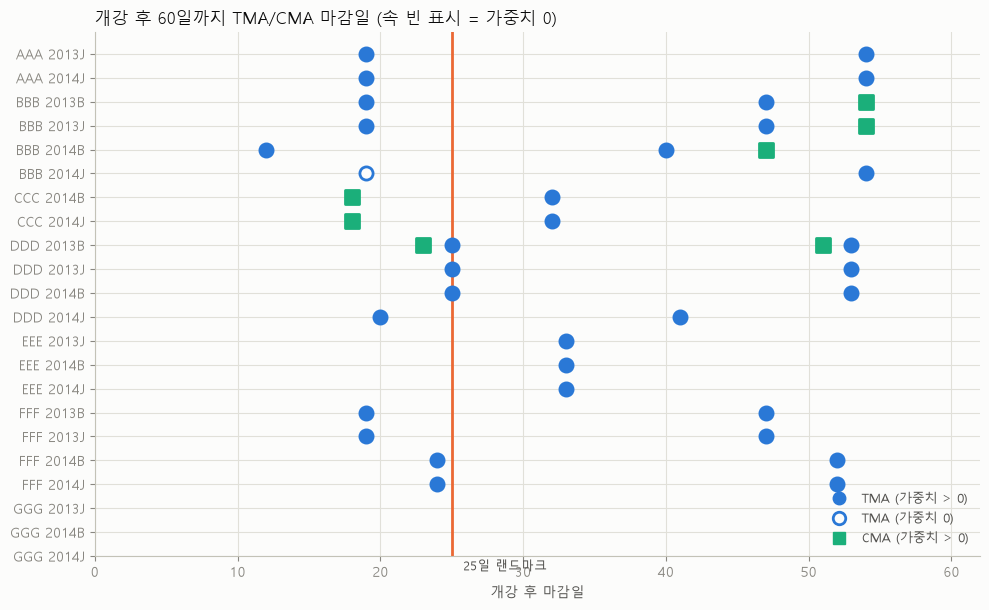

In [5]:
early = assessments[assessments['assessment_type'].isin(['TMA', 'CMA']) & (assessments['date'] <= 60)].copy()
early['표기'] = early['assessment_type'] + '@' + early['date'].astype(int).astype(str) + '(w' + early['weight'].astype(int).astype(str) + ')'
schedule = (early.sort_values('date').groupby(['code_module', 'code_presentation'])['표기']
            .agg(' '.join).unstack().reindex(index=MODULES, columns=TERMS))
print('개강 후 60일까지 TMA/CMA 일정 — 유형@마감일(w가중치)')
display(schedule.fillna('(없음)'))

pairs = [(m, t) for m in MODULES for t in TERMS if not np.isnan(n_mt.loc[m, t])]
fig, ax = plt.subplots(figsize=(10, 6.2))
for y, (m, t) in enumerate(pairs):
    sub = early[(early['code_module'] == m) & (early['code_presentation'] == t)]
    for _, r in sub.iterrows():
        color = C_STAY if r['assessment_type'] == 'TMA' else '#1baf7a'
        filled = r['weight'] > 0
        ax.scatter(r['date'], y, s=90, marker='o' if r['assessment_type'] == 'TMA' else 's',
                   facecolor=color if filled else SURFACE, edgecolor=color, linewidth=2, zorder=3)
ax.axvline(25, color=C_CHURN, linewidth=2, zorder=2)
ax.text(25.8, len(pairs) - 0.4, '25일 랜드마크', color=INK_2, fontsize=9)
ax.set_yticks(range(len(pairs)), [f'{m} {t}' for m, t in pairs])
ax.invert_yaxis()
ax.set_xlim(0, 62)
ax.set_xlabel('개강 후 마감일')
ax.set_title('개강 후 60일까지 TMA/CMA 마감일 (속 빈 표시 = 가중치 0)', loc='left')
ax.legend(handles=[
    Line2D([], [], marker='o', linestyle='', markersize=9, markerfacecolor=C_STAY, markeredgecolor=C_STAY, label='TMA (가중치 > 0)'),
    Line2D([], [], marker='o', linestyle='', markersize=9, markerfacecolor=SURFACE, markeredgecolor=C_STAY, markeredgewidth=2, label='TMA (가중치 0)'),
    Line2D([], [], marker='s', linestyle='', markersize=9, markerfacecolor='#1baf7a', markeredgecolor='#1baf7a', label='CMA (가중치 > 0)'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

**해석**

- **25일 안에 마감되는 평가는 과목·학기마다 다르다.**
  - AAA·FFF(2013): 19일 TMA / FFF(2014): 24일 TMA / CCC: 18일 CMA / BBB(2013B·2013J): 19일 TMA, BBB 2014B: 12일 TMA
  - DDD 2013B: 23일 CMA + 25일 TMA(**2회**) / DDD 2013J·2014B: 25일 TMA / **DDD 2014J: 20일 TMA**
  - EEE: 첫 평가가 33일 / GGG: 개강 후 60일까지 TMA·CMA 없음
- **BBB 2014J는 평가 설계가 바뀐 학기다.** 19일 TMA는 2013B·2013J와 같은 위치지만 가중치가 5 → 0이 됐고,
  다음 TMA도 47일(가중치 18) → 54일(가중치 10)로 바뀌었다. 기존 정의(`weight > 0`)였다면 이 학기 BBB
  학생 전원이 "25일 내 평가 기회 0"이 되어, 학습 때 한 번도 없던 "BBB × 기회 0" 조합이 생긴다.
- **DDD는 마감일이 랜드마크 당일(25일)에 걸린 학기가 많다.** 제출은 `date_submitted <= 25`만 인정하므로
  마감 당일 제출까지만 관측된다. 2014J는 마감이 20일로 당겨져 **제출을 관측할 여유가 5일 늘었다.**
  11절에서 DDD 2014J 제출자 비율이 급증한 것과 연결된다.

**다음 단계 반영**: 평가 피처는 학생 행동이면서 **과목 일정의 함수**다. 일정이 바뀐 학기(BBB 2014J,
DDD 2014J)가 모델링 과목별 성능에서 약하게 나오는지 확인한다.

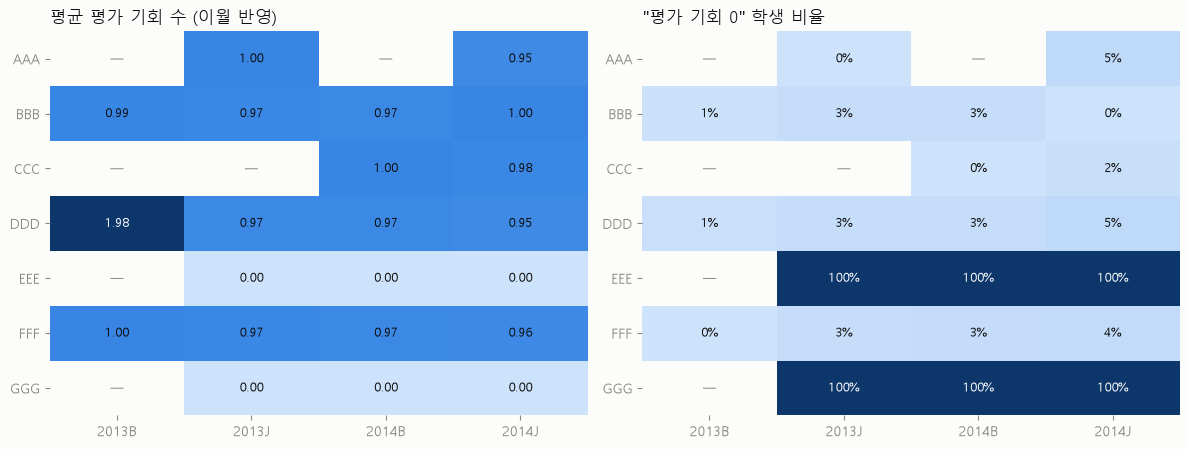

,min,max,size
code_presentation,,,
2013B,1.0,1.0,1585
2013J,1.0,1.0,1788
2014B,1.0,1.0,1242
2014J,1.0,1.0,1776


검증 통과: BBB 비이월 학생은 4개 학기 모두 평가 기회 1회 (2014J 구조 단절 해소)


In [6]:
opp_mean = model_df.pivot_table(index='code_module', columns='code_presentation', values='n_opportunity_25', aggfunc='mean').reindex(index=MODULES, columns=TERMS)
opp_zero = model_df.assign(z=model_df['n_opportunity_25'] == 0).pivot_table(index='code_module', columns='code_presentation', values='z', aggfunc='mean').reindex(index=MODULES, columns=TERMS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
heatmap(opp_mean, axes[0], fmt='{:.2f}', title='평균 평가 기회 수 (이월 반영)')
heatmap(opp_zero, axes[1], fmt='{:.0%}', title='"평가 기회 0" 학생 비율', vmin=0, vmax=1)
plt.tight_layout()
plt.show()

# 정의 변경 검증: BBB 2014J 비이월 학생의 기회 수가 다른 BBB 학기와 같은 1회인지
bbb = model_df[(model_df['code_module'] == 'BBB') & (model_df['n_banked_25'] == 0)]
bbb_opp = bbb.groupby('code_presentation')['n_opportunity_25'].agg(['min', 'max', 'size'])
display(bbb_opp)
assert (bbb_opp['min'] == 1).all() and (bbb_opp['max'] == 1).all(), 'BBB 비이월 학생의 평가 기회가 학기마다 1회가 아님'
print('검증 통과: BBB 비이월 학생은 4개 학기 모두 평가 기회 1회 (2014J 구조 단절 해소)')

**해석**

- 정의 변경(`weight` 조건 삭제, 이월 평가는 학생별 기회에서 제외) 후 **BBB의 비이월 학생은 4개 학기 모두
  평가 기회 1회**다. BBB 2014J의 구조 단절이 해소됐음을 `assert`로 고정했다.
- "기회 0" 비율은 EEE·GGG가 100%이고, 나머지 과목은 이월받은 재수강생 몫만큼만 0보다 크다
  (예: AAA 2014J 평균 기회 0.95 — 2013J 수강 후 재수강한 학생의 이월).
- `n_opportunity_25`는 이제 **과목 일정 − 이월 수**라서 학생마다 다를 수 있다.

**다음 단계 반영**: 05 공선성 노트북에서 `n_submitted + n_missing = n_opportunity` 등 항등식과
`n_banked_25` 추가 후 VIF를 다시 검증한다.

## 6. 이월(banked) 재수강생

**왜 보는가**: 재수강생은 과거 수강에서 받은 점수를 이월(`is_banked = 1`)받을 수 있다. 이월된 평가는 이번
학기에 낼 필요가 없다. 기존 정의는 이 평가를 **기회에는 넣고 제출에서는 빼서**, 이월자를 "기회는 있었는데
하나도 안 낸 학생"으로 만들었다. 미제출은 가장 강한 이탈 신호 중 하나이므로 오염 여부를 수치로 확인한다.

**무엇을 보는가**

- 학생을 평가 행동 상태로 나눈 이탈률: 기회 없음 / 이월 / 기회 있음·전부 미제출 / 일부 제출 / 전부 제출
- **기존 정의였다면** "전부 미제출"에 섞였을 이월자를 포함했을 때와 뺐을 때의 이탈률 차이

,행 수,이탈률
평가_상태,,
기회 없음(과목 일정),"4,990",10.8%
이월로 기회 없음,463,24.8%
전부 미제출,"2,902",41.5%
일부 제출,158,45.6%
전부 제출,"19,148",17.3%


,행 수,이탈률
"기존 정의 ""전부 미제출""","3,365",39.2%
"새 정의 ""전부 미제출""","2,902",41.5%
차이 = 이월자,463,24.8%


이월 보유 학생의 재수강 이력: {1: 369, 2: 79, 3: 12, 4: 3, 6: 1}


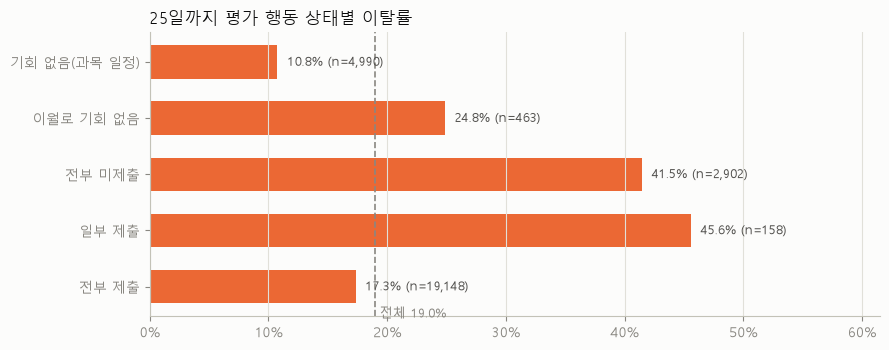

In [7]:
def assessment_state(d):
    return np.select(
        [
            (d['n_opportunity_25'] == 0) & (d['n_banked_25'] > 0),
            d['n_opportunity_25'] == 0,
            d['n_submitted_25'] == 0,
            d['n_submitted_25'] < d['n_opportunity_25'],
        ],
        ['이월로 기회 없음', '기회 없음(과목 일정)', '전부 미제출', '일부 제출'],
        default='전부 제출',
    )


model_df['평가_상태'] = assessment_state(model_df)
state_order = ['기회 없음(과목 일정)', '이월로 기회 없음', '전부 미제출', '일부 제출', '전부 제출']
state = model_df.groupby('평가_상태')[TARGET].agg(['size', 'mean']).reindex(state_order)
state.columns = ['행 수', '이탈률']
show(state, {'행 수': '{:,}', '이탈률': '{:.1%}'})

# 기존 정의 재현: 이월 평가도 기회로 셌다면 "전부 미제출"
old_missing_all = ((model_df['n_opportunity_25'] + model_df['n_banked_25']) > 0) & (model_df['n_submitted_25'] == 0)
new_missing_all = (model_df['n_opportunity_25'] > 0) & (model_df['n_submitted_25'] == 0)
contam = pd.DataFrame({
    '행 수': [old_missing_all.sum(), new_missing_all.sum(), (old_missing_all & ~new_missing_all).sum()],
    '이탈률': [model_df.loc[old_missing_all, TARGET].mean(), model_df.loc[new_missing_all, TARGET].mean(),
             model_df.loc[old_missing_all & ~new_missing_all, TARGET].mean()],
}, index=['기존 정의 "전부 미제출"', '새 정의 "전부 미제출"', '차이 = 이월자'])
show(contam, {'행 수': '{:,}', '이탈률': '{:.1%}'})
print('이월 보유 학생의 재수강 이력:', model_df.loc[model_df['n_banked_25'] > 0, 'num_of_prev_attempts'].value_counts().sort_index().to_dict())

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(state.index, state['이탈률'], color=C_CHURN, height=0.6)
for k, (n, r) in enumerate(zip(state['행 수'], state['이탈률'])):
    ax.text(r, k, f'  {r:.1%} (n={n:,})', va='center', fontsize=9, color=INK_2)
ax.axvline(model_df[TARGET].mean(), color=MUTED, linestyle='--', linewidth=1.2)
ax.text(model_df[TARGET].mean(), len(state) - 0.45, f' 전체 {model_df[TARGET].mean():.1%}', color=MUTED, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, state['이탈률'].max() * 1.35)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.grid(axis='y', visible=False)
ax.set_title('25일까지 평가 행동 상태별 이탈률', loc='left')
plt.tight_layout()
plt.show()

**해석**

| 상태 | 행 수 | 이탈률 | 의미 |
|---|---:|---:|---|
| 기회 없음(과목 일정) | 4,990 | 10.8% | EEE·GGG(저이탈 과목) 학생. 행동 신호가 아니라 **사실상 과목 식별** |
| 이월로 기회 없음 | 463 | 24.8% | 재수강생. 전체(19.0%)보다 높지만 미제출자보다 훨씬 낮음 |
| 전부 미제출 | 2,902 | **41.5%** | 가장 강한 위험 신호 |
| 일부 제출 | 158 | 45.6% | DDD 2013B(기회 2회)에서만 생김. 표본이 작아 해석하지 않음 |
| 전부 제출 | 19,148 | 17.3% | |

- **기존 정의의 오염을 수치로 확인했다.** 이월자까지 "전부 미제출"로 셌다면 3,365명·이탈률 39.2%였고,
  이월자 463명(24.8%)을 빼면 2,902명·**41.5%로 신호가 2.3%p 선명해진다.**
- 이월 보유 학생은 전원 재수강생이다(이전 시도 1회 369명, 2회 79명, 3회 이상 16명).

**다음 단계 반영**: `n_banked_25`를 피처 후보로 05 공선성 검증에 포함한다.

## 7. 수치형 피처 × 타깃 (전체)

**왜 보는가**: 각 수치형 피처가 이탈과 **어느 방향으로, 얼마나, 어떤 모양으로** 관계되는지 본다.

- **방향·강도**: 단일 피처 ROC-AUC(0.5 = 무관, 0.5에서 멀수록 강함). 모델 전에 신호 크기의 기준선을 잡는다.
- **모양**: 분위 구간별 이탈률. 관계가 단조인지, 특정 구간(예: 0)에서 꺾이는지 확인한다. 꺾임이 있으면
  선형 모델에는 플래그나 변환이 필요하다(`no_vle_activity_25`를 유지한 근거와 같은 논리).
- 결측이 있는 피처(`avg_score_25`, `avg_submit_delay_25`)는 제출자만으로 계산하고 결측 자체의 의미는
  12절에서 따로 본다.

,사용 행,잔류 중앙값,이탈 중앙값,단일 AUC,방향
피처,,,,,
avg_score_25,"19,299",78.0,70.0,0.631,값↑ 이탈↓
avg_submit_delay_25,"19,306",-1.0,0.0,0.608,값↑ 이탈↑
active_days_25,"27,661",9.0,8.0,0.570,값↑ 이탈↓
studied_credits,"27,661",60.0,60.0,0.568,값↑ 이탈↑
total_click_25,"27,661",176.0,134.0,0.563,값↑ 이탈↓
distinct_resources_25,"27,661",19.0,17.0,0.548,값↑ 이탈↓
n_submitted_25,"27,661",1.0,1.0,0.531,값↑ 이탈↓
date_registration,"27,654",-52.0,-58.0,0.528,값↑ 이탈↓
num_of_prev_attempts,"27,661",0.0,0.0,0.517,값↑ 이탈↑


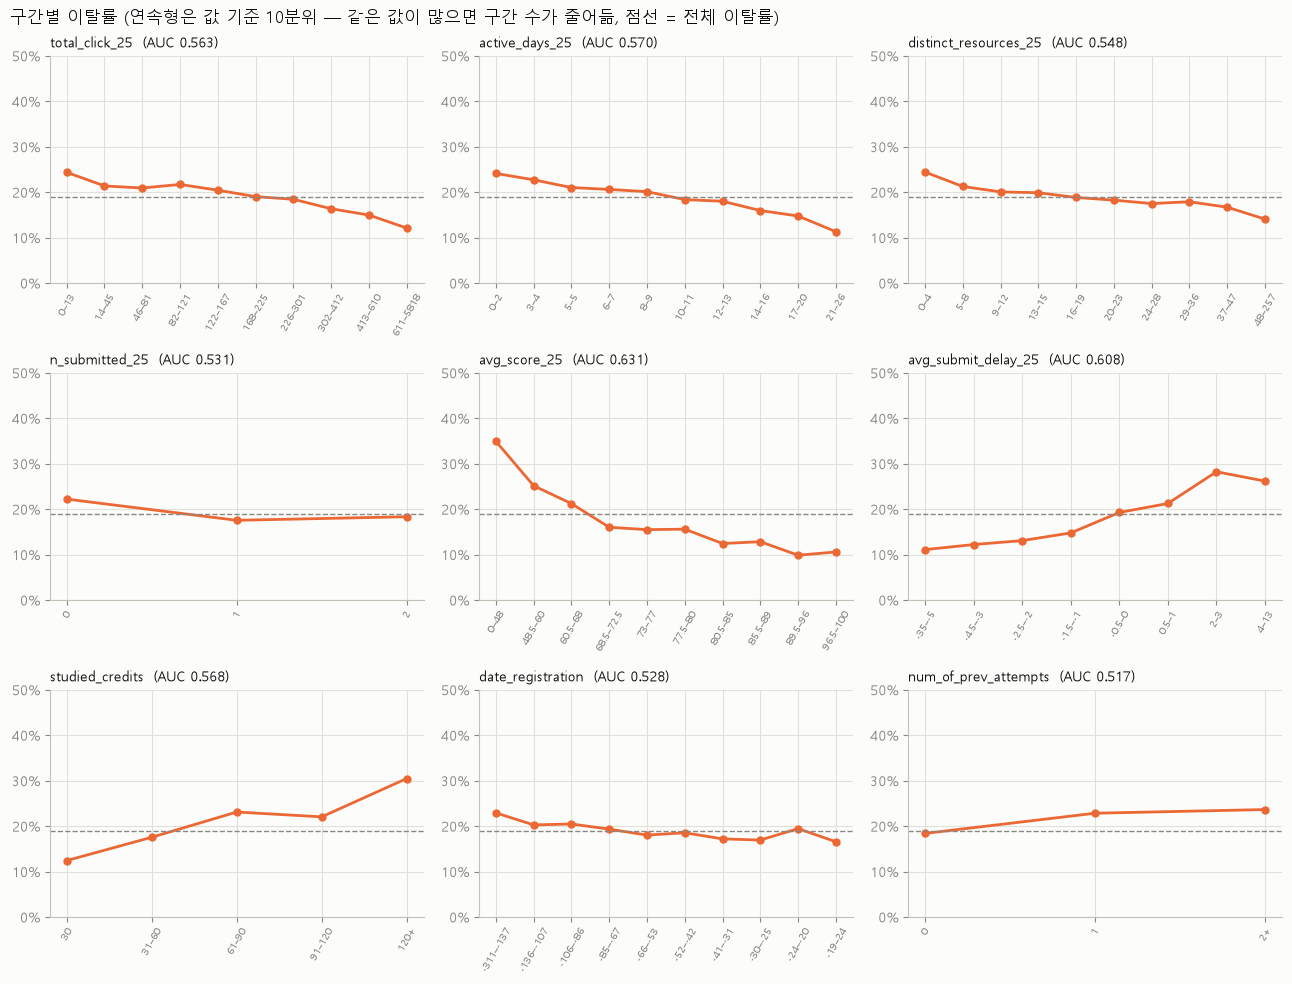

In [8]:
NUMERIC = ['total_click_25', 'active_days_25', 'distinct_resources_25', 'n_submitted_25', 'avg_score_25',
           'avg_submit_delay_25', 'studied_credits', 'date_registration', 'num_of_prev_attempts']

rows = []
for col in NUMERIC:
    sub = model_df[[col, TARGET]].dropna()
    auc = roc_auc_score(sub[TARGET], sub[col])
    rows.append({
        '피처': col,
        '사용 행': len(sub),
        '잔류 중앙값': sub.loc[sub[TARGET] == 0, col].median(),
        '이탈 중앙값': sub.loc[sub[TARGET] == 1, col].median(),
        '단일 AUC': max(auc, 1 - auc),
        '방향': '값↑ 이탈↑' if auc > 0.5 else '값↑ 이탈↓',
    })
uni = pd.DataFrame(rows).set_index('피처').sort_values('단일 AUC', ascending=False)
show(uni, {'사용 행': '{:,}', '잔류 중앙값': '{:.1f}', '이탈 중앙값': '{:.1f}', '단일 AUC': '{:.3f}'})

overall = model_df[TARGET].mean()
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.ravel(), NUMERIC):
    sub = model_df[[col, TARGET]].dropna()
    # 같은 값이 많은 피처는 순위로 자르면 같은 값이 다른 구간에 나뉘므로 값 기준으로 묶는다
    if col in ('n_submitted_25', 'num_of_prev_attempts'):
        key = sub[col].clip(upper=2)
        grp = sub.groupby(key)[TARGET].agg(['mean', 'size'])
        x = [f'{int(v)}' + ('+' if v == 2 and sub[col].max() > 2 else '') for v in grp.index]
    elif col == 'studied_credits':
        key = pd.cut(sub[col], [0, 30, 60, 90, 120, np.inf], labels=['30', '31–60', '61–90', '91–120', '120+'])
        grp = sub.groupby(key, observed=True)[TARGET].agg(['mean', 'size'])
        x = list(grp.index.astype(str))
    else:
        key = pd.qcut(sub[col], 10, duplicates='drop')
        grp = sub.groupby(key, observed=True).agg(mean=(TARGET, 'mean'), size=(TARGET, 'size'), lo=(col, 'min'), hi=(col, 'max'))
        x = [f'{lo:g}–{hi:g}' for lo, hi in zip(grp['lo'], grp['hi'])]
    ax.plot(range(len(grp)), grp['mean'], color=C_CHURN, marker='o', markersize=5)
    ax.axhline(overall, color=MUTED, linestyle='--', linewidth=1)
    ax.set_xticks(range(len(grp)), x, rotation=60, fontsize=7)
    ax.set_title(f'{col}  (AUC {uni.loc[col, "단일 AUC"]:.3f})', loc='left', fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_ylim(0, max(0.5, grp['mean'].max() * 1.1))
fig.suptitle('구간별 이탈률 (연속형은 값 기준 10분위 — 같은 값이 많으면 구간 수가 줄어듦, 점선 = 전체 이탈률)', x=0.01, ha='left', color=INK)
plt.tight_layout()
plt.show()

**해석**

- **단일 피처의 신호는 모두 약하다(AUC 0.52–0.63).** 한 피처로 이탈을 가를 수 없고, 조합과 과목 정보가
  필요하다. 베이스라인 모델의 ROC-AUC가 약 0.73이었던 것과 비교하면 조합 효과가 크다.
- **평가 점수가 가장 강하다(AUC 0.631, 제출자 한정).** 48점 이하 구간 이탈률 34.9%, 89점 초과 구간 약 10%다.
- **제출 시점도 강하다(0.608).** 마감 5일 이상 전 제출 11.1% → 마감 1–3일 후 제출 28.2%로 늦을수록 위험이 커진다.
- **VLE 활동 3종은 단조 감소**한다(클릭 하위 10% 24.4% → 상위 10% 12.1%). 최하위 구간에서 급격히
  꺾이지는 않는다.
- **수강 학점은 많을수록 위험하다.** 30학점 이하 12.4% → 120학점 초과 30.5%로 과부하 신호다.
- `n_submitted_25`는 0회 22.2% / 1회 17.5%로 약하게 보이는데, 0회에 저이탈 과목의 "기회 없음"이 섞여
  있어서다. 6·9절의 **상태 기준**으로 봐야 실제 신호(41.5% vs 17.3%)가 보인다.
- 재수강 이력: 0회 18.4% / 1회 22.8% / 2회 이상 23.6%. 등록일은 거의 신호가 없다(0.528).

**다음 단계 반영**

- 관계가 대부분 단조이고 극단 구간에서 뒤집히지 않으므로 **04의 "극단값 제거·캡핑 없음" 방침을 유지**한다.
- `n_submitted_25` 단독 해석은 과목 구조에 오염되므로, P5 해석은 기회 수와 함께 본다.

## 8. 활동량 × 타깃 × 과목 — 같은 클릭 수가 같은 위험인가

**왜 보는가**: 4절에서 과목마다 클릭 규모가 크게 달랐다. 모델은 `total_click_25` 하나로 모든 과목을
본다. **같은 절대 클릭 수가 과목마다 다른 위험을 뜻한다면**, 모델은 과목과의 상호작용을 따로 배워야
하고, 과목 내 상대 위치(백분위) 피처가 더 일관된 신호일 수 있다. 이 절은 그 후보 피처를 모델링에서
비교할 근거(사용자 결정: "모델링에서 비교 후 결정")를 만든다.

**무엇을 보는가**

1. 과목 × **절대** 클릭 구간 이탈률
2. 과목 × **과목·학기 내** 클릭 4분위 이탈률 — 과목마다 같은 방향·기울기인지

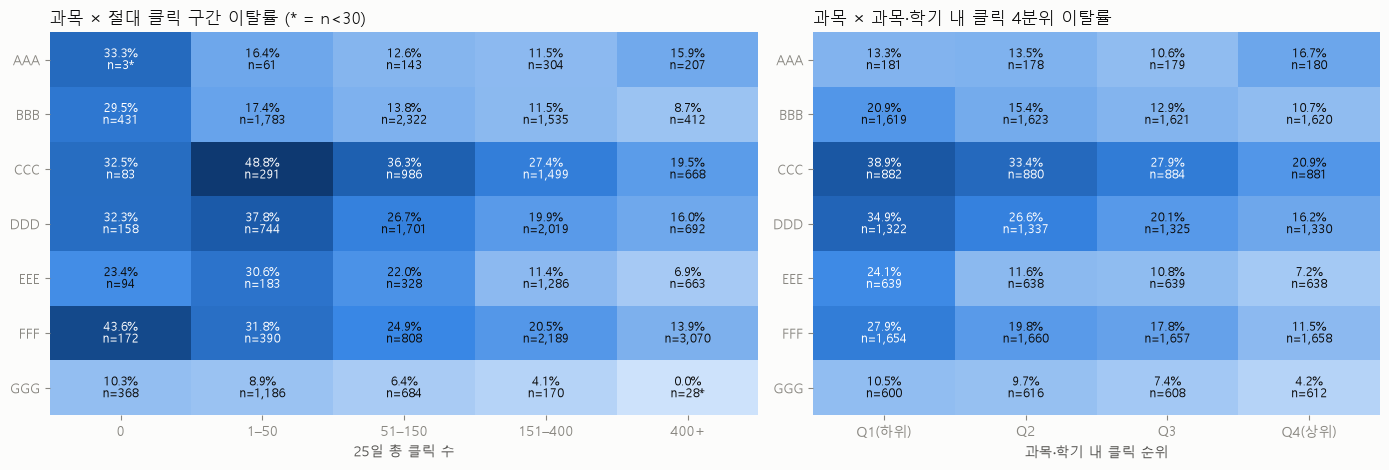

,Q1 이탈률,Q4 이탈률,Q1/Q4 배수,단조 감소
code_module,,,,
AAA,13.3%,16.7%,0.80,False
BBB,20.9%,10.7%,1.94,True
CCC,38.9%,20.9%,1.86,True
DDD,34.9%,16.2%,2.15,True
EEE,24.1%,7.2%,3.34,True
FFF,27.9%,11.5%,2.42,True
GGG,10.5%,4.2%,2.47,True


,기준,전체 단일 AUC
0,절대 클릭 수,0.563
1,과목·학기 내 클릭 백분위,0.604


In [9]:
bands = [-1, 0, 50, 150, 400, np.inf]
band_labels = ['0', '1–50', '51–150', '151–400', '400+']
model_df['클릭_절대구간'] = pd.cut(model_df['total_click_25'], bands, labels=band_labels)
abs_rate = model_df.pivot_table(index='code_module', columns='클릭_절대구간', values=TARGET, aggfunc='mean', observed=False).reindex(MODULES)
abs_n = model_df.pivot_table(index='code_module', columns='클릭_절대구간', values=TARGET, aggfunc='size', observed=False).reindex(MODULES).fillna(0)

# 과목·학기 안에서의 상대 위치 (학기별 규모 차이도 제거)
for col in ['total_click_25', 'active_days_25']:
    pct = model_df.groupby(['code_module', 'code_presentation'])[col].rank(pct=True, method='average')
    model_df[col + '_q'] = pd.cut(pct, [0, 0.25, 0.5, 0.75, 1.0], labels=['Q1(하위)', 'Q2', 'Q3', 'Q4(상위)'], include_lowest=True)
rel_rate = model_df.pivot_table(index='code_module', columns='total_click_25_q', values=TARGET, aggfunc='mean', observed=False).reindex(MODULES)
rel_n = model_df.pivot_table(index='code_module', columns='total_click_25_q', values=TARGET, aggfunc='size', observed=False).reindex(MODULES)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={'width_ratios': [5, 4]})
heatmap(abs_rate, axes[0], counts=abs_n, title='과목 × 절대 클릭 구간 이탈률 (* = n<30)', vmin=0, vmax=0.5)
axes[0].set_xlabel('25일 총 클릭 수')
heatmap(rel_rate, axes[1], counts=rel_n, title='과목 × 과목·학기 내 클릭 4분위 이탈률', vmin=0, vmax=0.5)
axes[1].set_xlabel('과목·학기 내 클릭 순위')
plt.tight_layout()
plt.show()

# 과목 내 4분위의 기울기가 과목마다 같은 방향인지
slope = pd.DataFrame({
    'Q1 이탈률': rel_rate.iloc[:, 0],
    'Q4 이탈률': rel_rate.iloc[:, -1],
})
slope['Q1/Q4 배수'] = slope['Q1 이탈률'] / slope['Q4 이탈률']
slope['단조 감소'] = rel_rate.apply(lambda r: bool(np.all(np.diff(r.to_numpy()) <= 0.005)), axis=1)
show(slope, {'Q1 이탈률': '{:.1%}', 'Q4 이탈률': '{:.1%}', 'Q1/Q4 배수': '{:.2f}'})

# 절대 기준 vs 상대 기준 단일 AUC (과목별 → 전체 풀링)
pooled = pd.DataFrame({
    '기준': ['절대 클릭 수', '과목·학기 내 클릭 백분위'],
    '전체 단일 AUC': [
        1 - roc_auc_score(model_df[TARGET], model_df['total_click_25']),
        1 - roc_auc_score(model_df[TARGET], model_df.groupby(['code_module', 'code_presentation'])['total_click_25'].rank(pct=True)),
    ],
})
show(pooled, {'전체 단일 AUC': '{:.3f}'})

**해석**

- **같은 절대 클릭 수가 과목마다 다른 위험을 뜻한다.**
  - 25일 클릭 0회: FFF 43.6% vs GGG 10.3%
  - 151–400회: CCC 27.4% vs GGG 4.1%
  - GGG의 400회 이상은 28명뿐이고, AAA의 0회는 3명뿐이다(`*`) — 절대 구간은 과목마다 표본이 극단적으로 치우친다.
- **과목·학기 안의 상대 위치로 보면 패턴이 일관된다.** AAA를 제외한 6개 과목에서 클릭 하위 25%(Q1) →
  상위 25%(Q4)로 이탈률이 단조 감소하고, Q1이 Q4의 1.86–3.34배다.
  - AAA는 비단조(Q1 13.3%, Q4 16.7%)인데, 과목 전체 718행·분위당 약 180명이라 판단을 보류한다.
- **단일 AUC도 상대 기준이 높다.** 절대 클릭 0.563 → 과목·학기 내 백분위 0.604(+0.041).
- 상대 백분위는 **25일 시점에 그 학기 재학생 전체의 25일 데이터로 계산 가능**하므로 누수가 아니다.

**다음 단계 반영**: 사용자 결정대로 **모델링에서 "기본 피처셋 vs 과목·학기 내 상대 피처 추가"를 같은
검증으로 비교**한다. 트리 모델은 `code_module × 클릭` 상호작용을 스스로 학습할 수 있어, 모델 성능 차이는
단일 AUC 차이보다 작을 수 있다(감사 실험 +0.005).

## 9. 평가 행동 × 타깃 × 과목

**왜 보는가**: 6절의 평가 상태별 이탈률이 **과목마다 같은 방향인지** 확인한다. 방향이 같으면 통합 모델이
다른 과목의 패턴을 빌려 쓰는 것이 타당하고(과목별 모델보다 통합 모델이 나았던 이유,
`07_pipeline_audit_before_final.md` 4.5절), 방향이 다르면 과목 상호작용이 필요하다.
또한 **평가 기회가 구조적으로 없는 과목(EEE, GGG)은 평가 피처로 학생을 구분할 수 없다**는 점을 확인한다.

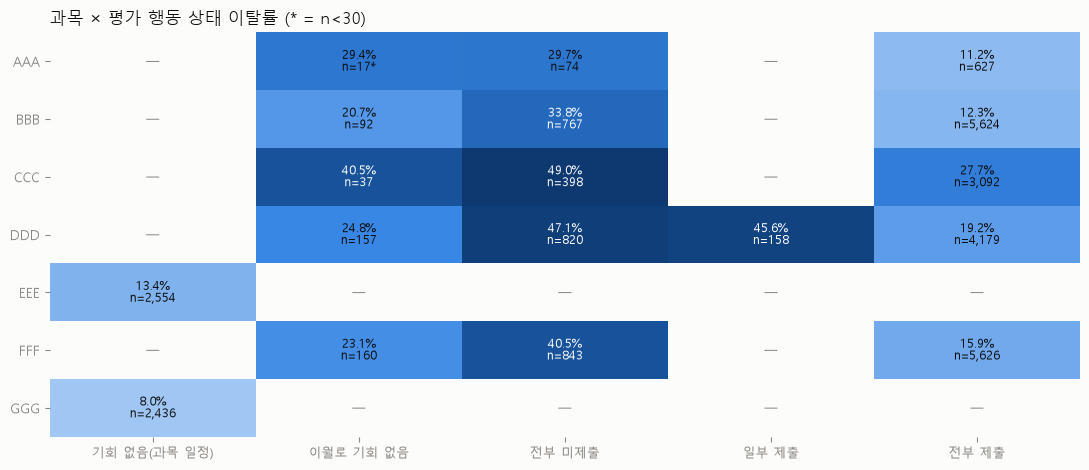

,미제출 이탈률,제출 이탈률,배수
code_module,,,
AAA,29.7%,11.2%,2.66
BBB,33.8%,12.3%,2.74
CCC,49.0%,27.7%,1.77
DDD,47.1%,20.2%,2.34
FFF,40.5%,15.9%,2.54


평가 기회가 전혀 없는 과목: ['EEE', 'GGG']


In [10]:
st_rate = model_df.pivot_table(index='code_module', columns='평가_상태', values=TARGET, aggfunc='mean').reindex(index=MODULES, columns=state_order)
st_n = model_df.pivot_table(index='code_module', columns='평가_상태', values=TARGET, aggfunc='size').reindex(index=MODULES, columns=state_order)

fig, ax = plt.subplots(figsize=(11, 4.8))
heatmap(st_rate, ax, counts=st_n.fillna(0), title='과목 × 평가 행동 상태 이탈률 (* = n<30)', vmin=0, vmax=0.5)
ax.set_xticks(range(len(state_order)), state_order, fontsize=9)
plt.tight_layout()
plt.show()

with_opp = model_df[model_df['n_opportunity_25'] > 0]
ratio = with_opp.groupby(['code_module', with_opp['n_submitted_25'] > 0])[TARGET].mean().unstack()
ratio.columns = ['미제출 이탈률', '제출 이탈률']
ratio['배수'] = ratio['미제출 이탈률'] / ratio['제출 이탈률']
show(ratio.reindex([m for m in MODULES if m in ratio.index]), {'미제출 이탈률': '{:.1%}', '제출 이탈률': '{:.1%}', '배수': '{:.2f}'})
print('평가 기회가 전혀 없는 과목:', [m for m in MODULES if (model_df.loc[model_df['code_module'] == m, 'n_opportunity_25'] == 0).all()])

**해석**

- **평가 기회가 있는 5개 과목 모두 미제출자의 이탈률이 제출자의 1.77(CCC)–2.74(BBB)배**다. 방향이 전
  과목에서 같으므로, 통합 모델이 과목 간 "미제출 = 위험" 패턴을 공유하는 것이 타당하다(과목별 모델보다
  통합 모델이 나았던 이유, `07_pipeline_audit_before_final.md` 4.5절).
- **EEE·GGG는 25일 안에 평가가 전혀 없다.** 두 과목 학생은 평가 피처가 모두 0 또는 결측이라, 모델은 VLE
  활동과 인구통계만으로 예측한다. GGG는 활동량도 가장 적어(4절) **학생을 구분할 신호 자체가 부족하다.**
  베이스라인 모델에서 GGG가 가장 약했던 원인이다.

**다음 단계 반영**: 모델링 과목별 성능표에서 EEE·GGG를 **"25일 평가 신호 없는 과목"**으로 구분해 보고하고,
P5에서 이 과목들의 예측 한계를 명시한다.

## 10. 범주형 피처 × 타깃

**왜 보는가**: 범주별 이탈률과 표본 수를 함께 봐서 (1) 신호가 있는 범주형 피처와 (2) 표본이 작아 원-핫
더미가 불안정할 범주(열린 이슈: `region` 13개, `imd_band` 11개)를 확인한다.

두 번째 표는 **성별 × 과목 교란**을 확인한다. 4절에서 과목별 성비가 크게 달랐으므로, 전체 성별
이탈률 차이가 과목 구성 때문인지(과목 안에서는 차이가 없는지) 확인한다. 이 결과는 P5에서 `gender`
계수를 해석할 때의 근거가 된다(`0912_03` 결정 문서 5절).

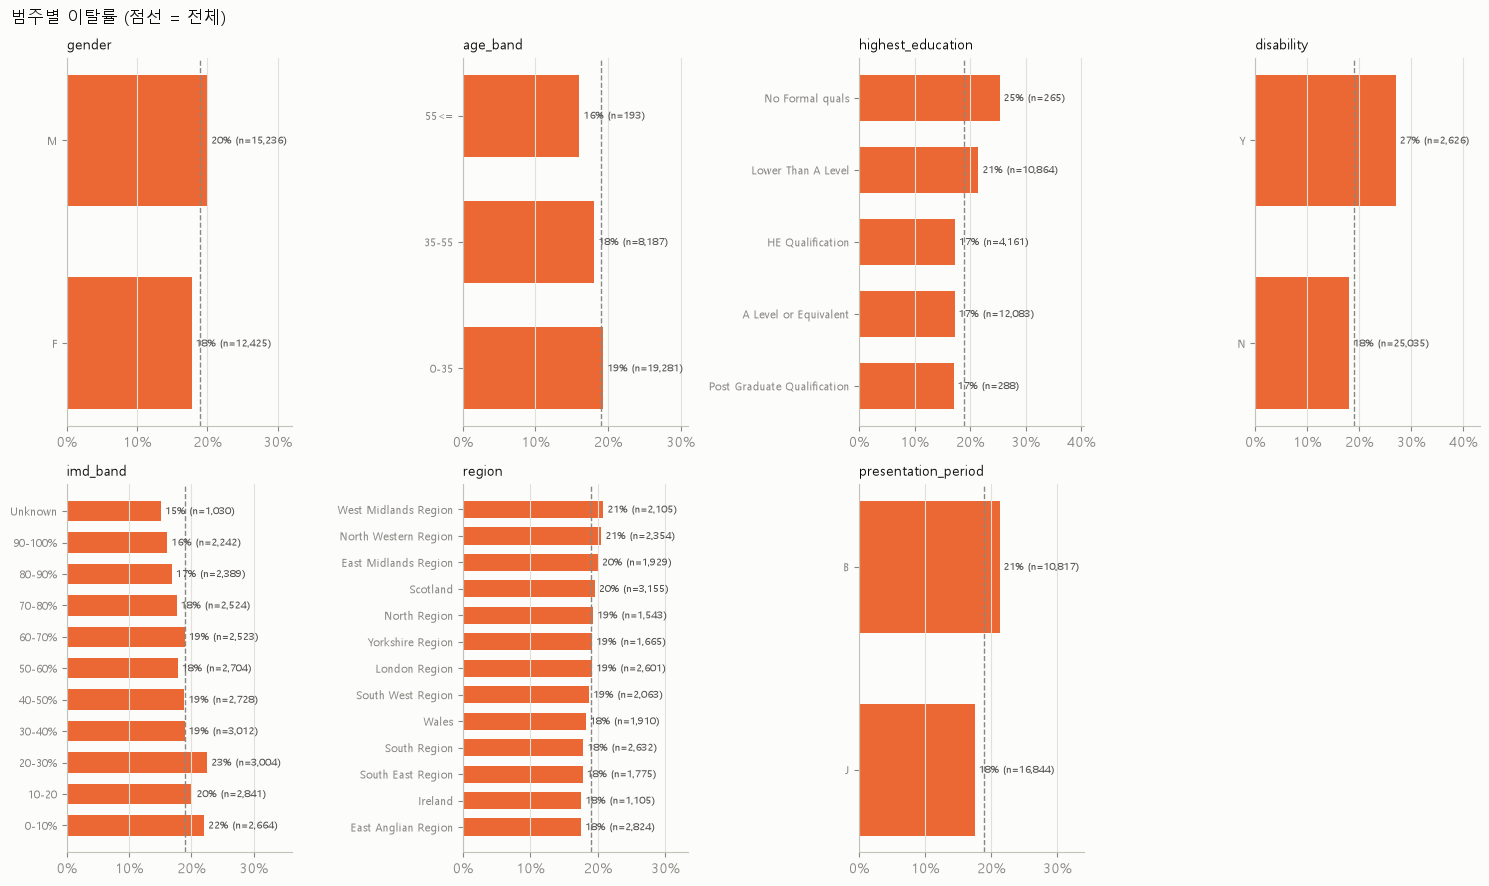

,범주 수,이탈률 최소,이탈률 최대,최소 표본,최소 표본 범주
피처,,,,,
gender,2,17.7%,20.0%,"12,425",F
age_band,3,16.1%,19.4%,193,55<=
highest_education,5,17.0%,25.3%,265,No Formal quals
disability,2,18.1%,27.0%,"2,626",Y
imd_band,11,15.1%,22.5%,"1,030",Unknown
region,13,17.5%,20.8%,"1,105",Ireland
presentation_period,2,17.5%,21.2%,"10,817",B


In [11]:
CATS = ['gender', 'age_band', 'highest_education', 'disability', 'imd_band', 'region', 'presentation_period']
cat_df = model_df.assign(imd_band=model_df['imd_band'].fillna('Unknown'), presentation_period=model_df['code_presentation'].str[-1])

fig, axes = plt.subplots(2, 4, figsize=(15, 9))
cat_rows = []
for ax, col in zip(axes.ravel(), CATS):
    g = cat_df.groupby(col)[TARGET].agg(['mean', 'size'])
    if col in ('imd_band', 'age_band'):
        g = g.sort_index()
    else:
        g = g.sort_values('mean')
    ax.barh([str(i) for i in g.index], g['mean'], color=C_CHURN, height=0.65)
    for k, (m, n) in enumerate(zip(g['mean'], g['size'])):
        ax.text(m, k, f' {m:.0%} (n={n:,})', va='center', fontsize=7.5, color=INK_2)
    ax.axvline(overall, color=MUTED, linestyle='--', linewidth=1)
    ax.set_xlim(0, g['mean'].max() * 1.6)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', visible=False)
    ax.set_title(col, loc='left', fontsize=10)
    cat_rows.append({'피처': col, '범주 수': len(g), '이탈률 최소': g['mean'].min(), '이탈률 최대': g['mean'].max(),
                     '최소 표본': g['size'].min(), '최소 표본 범주': g['size'].idxmin()})
axes.ravel()[-1].axis('off')
fig.suptitle('범주별 이탈률 (점선 = 전체)', x=0.01, ha='left', color=INK)
plt.tight_layout()
plt.show()
show(pd.DataFrame(cat_rows).set_index('피처'), {'이탈률 최소': '{:.1%}', '이탈률 최대': '{:.1%}', '최소 표본': '{:,}'})

**해석**

- **장애 여부가 뚜렷하다**: Y 27.0%(n=2,626) vs N 약 18%.
- **최종 학력**: `No Formal quals` 25.3%(n=265) > `Lower Than A Level` 21% > 나머지 17% 안팎. 양 끝 범주는
  표본이 300명 미만이다.
- **IMD**: 빈곤 하위 구간(0–10% 22%, 20–30% 22.5%)이 상위 구간(90–100% 16%)보다 높다. `Unknown`은 15.1%로
  오히려 가장 낮다(12절).
- **지역**: 13개 지역 이탈률이 17.5–20.8%로 **차이가 작다.** 13개 원-핫 더미가 주는 신호에 비해 복잡도가 크다.
- `age_band`의 `55<=`는 193명뿐이다. 개강 시기는 B 21.2% vs J 17.5%다.

**다음 단계 반영**: `region` 희소 더미 병합·제거 여부(열린 이슈)는 이 표를 근거로 **모델링 해석 단계에서
permutation importance와 함께** 판단한다.

In [12]:
g_overall = model_df.groupby('gender')[TARGET].mean()
g_mod = model_df.pivot_table(index='code_module', columns='gender', values=TARGET, aggfunc='mean').reindex(MODULES)
g_mod['차이(M-F)'] = g_mod['M'] - g_mod['F']
g_mod['여성 비율'] = profile['여성_비율']
show(g_mod, {'F': '{:.1%}', 'M': '{:.1%}', '차이(M-F)': '{:+.1%}', '여성 비율': '{:.0%}'})

# 과목 구성을 고정했을 때의 성별 차이: 과목별 차이를 전체 행 수로 가중 평균
w = model_df['code_module'].value_counts().reindex(MODULES)
adjusted = np.average(g_mod['차이(M-F)'], weights=w)
print(f'전체 성별 이탈률 차이(M-F): {g_overall["M"] - g_overall["F"]:+.2%}')
print(f'과목 내 차이의 가중 평균(M-F): {adjusted:+.2%}')

gender,F,M,차이(M-F),여성 비율
code_module,,,,
AAA,15.7%,12.0%,-3.7%,41%
BBB,15.1%,13.7%,-1.4%,88%
CCC,29.9%,30.4%,+0.6%,24%
DDD,27.8%,22.3%,-5.5%,40%
EEE,16.8%,13.0%,-3.8%,11%
FFF,21.2%,18.8%,-2.4%,18%
GGG,7.7%,9.0%,+1.3%,81%


전체 성별 이탈률 차이(M-F): +2.22%
과목 내 차이의 가중 평균(M-F): -2.22%


**해석 — 심슨의 역설**

- **전체로 보면 남성의 이탈률이 2.2%p 높다**(M 20.0% vs F 17.7%).
- **그런데 과목 안에서 보면 7개 중 5개 과목에서 여성이 더 높고**(DDD −5.5%p, EEE −3.8%p, AAA −3.7%p 등),
  과목 내 차이의 가중 평균은 **−2.2%p로 방향이 뒤집힌다.**
- 원인은 과목 구성이다. 여성이 가장 많은 BBB(88%)·GGG(81%)는 이탈률 15.0%·8.0%의 저이탈 과목이고,
  남성이 많은 과목 중 CCC(남성 76%, 이탈률 30.3%)·FFF(82%, 19.2%)는 고이탈·중간 과목이다(EEE는 남성 89%지만
  13.4%로 예외). 전체 비교의 "남성이 더 이탈한다"는 **성별 효과가 아니라 과목 구성의 효과**다.

**다음 단계 반영**

- `gender`와 `code_module`을 함께 모델에 두는 05 결정(Cramér's V 0.601, 둘 다 유지)을 유지한다. 둘 중
  하나만 넣으면 이 교란이 계수에 그대로 들어간다.
- P5에서 `gender` 효과는 **반드시 과목을 통제한 상태로만** 해석하고, 전체 비율 비교를 결론으로 쓰지 않는다.

## 11. 학기 간 분포 이동

**왜 보는가**: 모델은 2013B·2013J·2014B로 학습하고 2014J로 평가한다. 과목 안에서 학기마다 **피처 분포**가
움직이면 같은 모델 점수가 다른 위험을 뜻하게 되고, **기준 이탈률**이 움직이면 확률 수준이 틀어진다.
어느 과목이 가장 불안정한지 확인해 모델링의 학기 단위 검증·과목별 성능 보고의 초점을 정한다.

**주의**: 2014J의 이탈률도 표에 나오지만, 이것으로 피처·임계값을 고르지 않는다. 불안정성의 **존재와
위치**를 확인하는 용도다.

**무엇을 보는가**

1. 과목별 학기 흐름: 이탈률, 클릭 중앙값, 평가 제출률(기회 있는 학생 중 1건 이상 제출)
2. 개발 학기 대비 2014J 표준화 평균 차이(SMD) — |SMD| ≥ 0.2면 작지 않은 이동으로 본다

이탈률


code_presentation,2013B,2013J,2014B,2014J
code_module,,,,
AAA,,13.0%,,14.1%
BBB,20.8%,13.4%,12.4%,13.2%
CCC,,,31.7%,29.2%
DDD,26.4%,24.1%,28.7%,20.3%
EEE,,12.9%,14.3%,13.4%
FFF,20.0%,19.2%,20.3%,17.9%
GGG,,4.0%,8.1%,12.9%


클릭_중앙값


code_presentation,2013B,2013J,2014B,2014J
code_module,,,,
AAA,,282,,244
BBB,119,78,73,90
CCC,,,194,197
DDD,197,157,161,128
EEE,,283,240,271
FFF,389,362,334,386
GGG,,24,31,43


제출자_비율


code_presentation,2013B,2013J,2014B,2014J
code_module,,,,
AAA,,90.3%,,88.5%
BBB,79.9%,88.0%,90.4%,93.6%
CCC,,,85.7%,90.8%
DDD,86.8%,79.8%,77.8%,91.4%
EEE,,,,
FFF,87.3%,89.6%,83.2%,86.5%
GGG,,,,


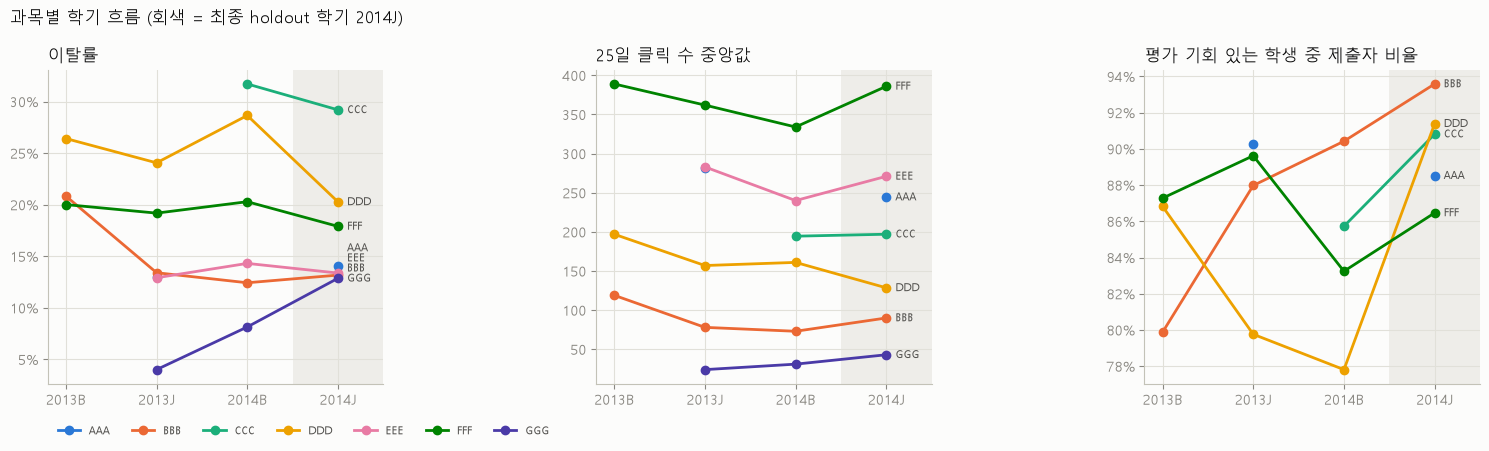

In [13]:
trend = model_df.groupby(['code_module', 'code_presentation']).agg(
    이탈률=(TARGET, 'mean'),
    클릭_중앙값=('total_click_25', 'median'),
    활동일_중앙값=('active_days_25', 'median'),
).reset_index()
submit = (model_df[model_df['n_opportunity_25'] > 0]
          .groupby(['code_module', 'code_presentation'])['n_submitted_25'].apply(lambda s: (s > 0).mean())
          .rename('제출자_비율').reset_index())
trend = trend.merge(submit, on=['code_module', 'code_presentation'], how='left')
for col, f in [('이탈률', '{:.1%}'), ('클릭_중앙값', '{:.0f}'), ('제출자_비율', '{:.1%}')]:
    print(col)
    show(trend.pivot(index='code_module', columns='code_presentation', values=col).reindex(index=MODULES, columns=TERMS),
         {t: f for t in TERMS})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (col, title, fmt) in zip(axes, [
    ('이탈률', '이탈률', lambda v, _: f'{v:.0%}'),
    ('클릭_중앙값', '25일 클릭 수 중앙값', lambda v, _: f'{v:.0f}'),
    ('제출자_비율', '평가 기회 있는 학생 중 제출자 비율', lambda v, _: f'{v:.0%}'),
]):
    end_labels = []
    for m in MODULES:
        s = trend[trend['code_module'] == m].set_index('code_presentation').reindex(TERMS)[col]
        if s.notna().sum() == 0:
            continue
        # 개설되지 않은 학기(NaN)는 선을 끊어 이어진 것처럼 보이지 않게 한다
        ax.plot(range(len(TERMS)), s.to_numpy(dtype=float), color=MODULE_COLORS[m], marker='o', markersize=6, label=m)
        end_labels.append((s.dropna().iloc[-1], m))
    ys = [v for v, _ in end_labels]
    span = (max(ys) - min(ys)) or 1
    placed = []
    for v, m in sorted(end_labels):
        y = v if not placed else max(v, placed[-1] + span * 0.06)
        placed.append(y)
        ax.text(len(TERMS) - 1 + 0.1, y, m, color=INK_2, fontsize=8, va='center')
    ax.set_xticks(range(len(TERMS)), TERMS)
    ax.set_xlim(-0.2, len(TERMS) - 0.5)
    ax.axvspan(2.5, 3.5, color=GRID, alpha=0.5, linewidth=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt))
    ax.set_title(title, loc='left')
axes[0].legend(ncol=7, loc='upper left', bbox_to_anchor=(0, -0.1), fontsize=8)
fig.suptitle('과목별 학기 흐름 (회색 = 최종 holdout 학기 2014J)', x=0.01, ha='left', color=INK)
plt.tight_layout()
plt.show()

**해석**

- **이탈률**: GGG가 4.0% → 8.1% → 12.9%로 계속 오르고, DDD는 2014J에 20.3%로 떨어진다(3절).
- **클릭 중앙값**: DDD는 197 → 157 → 161 → 128로 줄고, GGG는 24 → 31 → 43으로 늘었다.
  FFF는 334(2014B) → 386(2014J)로 반등했다.
- **제출자 비율이 일정 변화를 따라 움직인다.**
  - DDD: 86.8% → 79.8% → 77.8% → **91.4%**. 마감 25일(당일)이던 학기는 낮고, 20일로 당겨진 2014J에 급증했다.
    2013B는 23일 CMA가 있어 상대적으로 높다(5절).
  - BBB: 79.9% → 88.0% → 90.4% → 93.6%로 계속 오른다.
  - CCC: 85.7% → 90.8%.
- 즉 **제출 피처의 학기 간 차이 일부는 학생 행동 변화가 아니라 평가 일정 변화**다.

**다음 단계 반영**: 학기가 바뀌면 피처 의미가 달라지는 과목이 있으므로, 모델링에서 **학기 단위 검증
(한 학기를 통째로 빼는 검증)**을 보조 지표로 보고, 모델 선택 시 학기 간 안정성을 함께 본다.

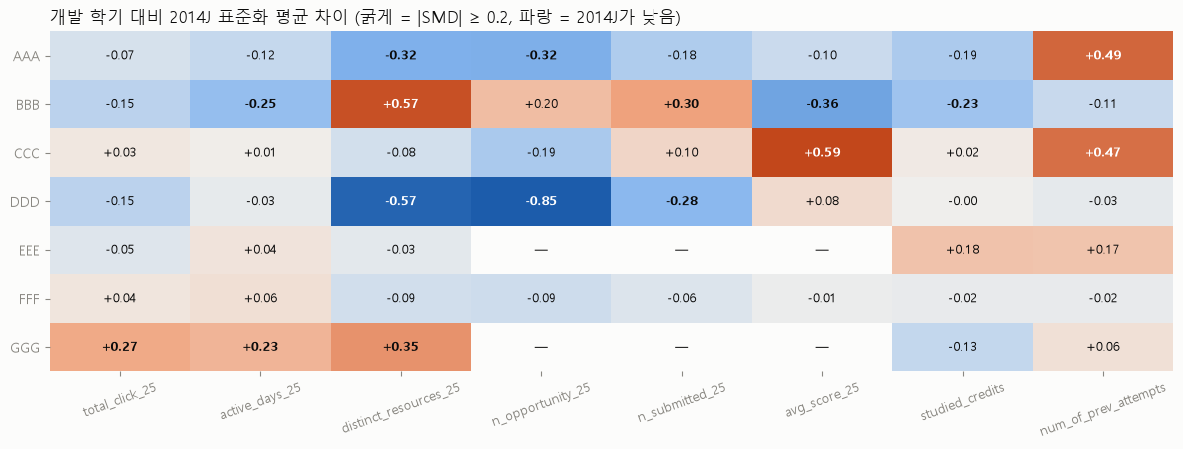

|SMD| >= 0.2 인 (과목, 피처):
DDD  n_opportunity_25         0.85
CCC  avg_score_25             0.59
DDD  distinct_resources_25    0.57
BBB  distinct_resources_25    0.57
AAA  num_of_prev_attempts     0.49
CCC  num_of_prev_attempts     0.47
BBB  avg_score_25             0.36
GGG  distinct_resources_25    0.35
AAA  n_opportunity_25         0.32
     distinct_resources_25    0.32
BBB  n_submitted_25           0.30
DDD  n_submitted_25           0.28
GGG  total_click_25           0.27
BBB  active_days_25           0.25
GGG  active_days_25           0.23
BBB  studied_credits          0.23


In [14]:
SMD_FEATURES = ['total_click_25', 'active_days_25', 'distinct_resources_25', 'n_opportunity_25', 'n_submitted_25',
                'avg_score_25', 'studied_credits', 'num_of_prev_attempts']


def smd(a, b):
    a, b = a.dropna(), b.dropna()
    pooled_sd = np.sqrt((a.var() + b.var()) / 2)
    return np.nan if pooled_sd == 0 or len(a) == 0 or len(b) == 0 else (b.mean() - a.mean()) / pooled_sd


smd_rows = {}
for m in MODULES:
    d = model_df[model_df['code_module'] == m]
    dev, hold = d[d['code_presentation'] != '2014J'], d[d['code_presentation'] == '2014J']
    smd_rows[m] = {f: smd(dev[f], hold[f]) for f in SMD_FEATURES}
smd_table = pd.DataFrame(smd_rows).T.reindex(MODULES)

fig, ax = plt.subplots(figsize=(12, 4.6))
DIV = LinearSegmentedColormap.from_list('div', ['#1c5cab', '#86b6ef', '#f0efec', '#f0a47f', '#c2461a'])
data = smd_table.to_numpy(dtype=float)
ax.imshow(np.ma.masked_invalid(data), cmap=DIV, vmin=-0.6, vmax=0.6, aspect='auto')
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        ax.text(j, i, '—' if np.isnan(v) else f'{v:+.2f}', ha='center', va='center', fontsize=9,
                color=INK if np.isnan(v) or abs(v) < 0.4 else '#ffffff', fontweight='bold' if not np.isnan(v) and abs(v) >= 0.2 else 'normal')
ax.set_xticks(range(len(SMD_FEATURES)), SMD_FEATURES, rotation=20, fontsize=9)
ax.set_yticks(range(len(MODULES)), MODULES)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('개발 학기 대비 2014J 표준화 평균 차이 (굵게 = |SMD| ≥ 0.2, 파랑 = 2014J가 낮음)', loc='left')
plt.tight_layout()
plt.show()

big = smd_table.abs().stack()
print('|SMD| >= 0.2 인 (과목, 피처):')
print(big[big >= 0.2].sort_values(ascending=False).round(2).to_string())

**해석**

- **가장 큰 이동**: DDD `n_opportunity_25` −0.85(개발 학기에 기회 2회인 2013B가 있음), CCC `avg_score_25` +0.59,
  DDD·BBB `distinct_resources_25` ∓0.57.
- **재수강 이력 이동은 구조적이다**: AAA +0.49, CCC +0.47. 두 과목은 개발 세트에 **첫 개설 학기만** 들어
  있어(AAA 2013J, CCC 2014B) 재수강생이 거의 없고, 다음 학기인 2014J에 재수강생이 생긴다. AAA의
  `n_opportunity_25` −0.32도 그 재수강생들의 이월 때문이다.
- **GGG는 활동 3종이 모두 증가**했다(+0.23–+0.35). 이탈률이 함께 오른 과목이라, "활동이 늘면 덜 이탈한다"는
  학습 패턴과 반대 방향으로 움직였다.
- **FFF·EEE는 모든 피처가 |SMD| < 0.2로 안정적**이다.
- `distinct_resources_25`는 과목에 올라온 자료 수에 좌우되므로 학기 간 이동이 크다.

**다음 단계 반영**

- 상대 피처 비교(8절)에 클릭·활동일과 함께 `distinct_resources_25`도 포함한다.
- 모델링의 과목별 holdout 성능이 이 표(이동이 큰 BBB·DDD·GGG)와 연결되는지 확인한다.

## 12. 결측 패턴 × 타깃

**왜 보는가**: 04 노트북의 결측 처리 결정 전에 **결측이 무엇을 뜻하고 이탈과 어떻게 연결되는지** 본다.
결측이 이탈과 강하게 연결되면 결측 자체가 신호이므로 지우거나 무작정 채우면 안 된다.

- `avg_score_25`·`avg_submit_delay_25`: 결측 원인(기회 없음 / 이월로 기회 없음 / 미제출 / 제출했으나 점수 없음)별 이탈률
- `imd_band`: 지역별 결측률과 결측 여부별 이탈률 — **기존 해석("잉글랜드 외 지역이라 결측")이 데이터와 맞는지 검증**
- `date_registration`: 결측 7행

In [15]:
reason = np.select(
    [
        model_df['avg_score_25'].notna(),
        (model_df['n_opportunity_25'] == 0) & (model_df['n_banked_25'] > 0),
        model_df['n_opportunity_25'] == 0,
        model_df['n_submitted_25'] == 0,
    ],
    ['값 있음', '이월로 기회 없음', '기회 없음(과목 일정)', '기회 있으나 미제출'],
    default='제출했으나 점수 없음',
)
miss = model_df.groupby(reason)[TARGET].agg(['size', 'mean']).reindex(['값 있음', '기회 없음(과목 일정)', '이월로 기회 없음', '기회 있으나 미제출', '제출했으나 점수 없음'])
miss.columns = ['행 수', '이탈률']
print('avg_score_25 결측 원인별')
show(miss, {'행 수': '{:,}', '이탈률': '{:.1%}'})
print('NaN 개수 — avg_score_25:', model_df['avg_score_25'].isna().sum(), '/ avg_submit_delay_25:', model_df['avg_submit_delay_25'].isna().sum())

avg_score_25 결측 원인별


,행 수,이탈률
값 있음,"19,299",17.5%
기회 없음(과목 일정),"4,990",10.8%
이월로 기회 없음,463,24.8%
기회 있으나 미제출,"2,902",41.5%
제출했으나 점수 없음,7,85.7%


NaN 개수 — avg_score_25: 8362 / avg_submit_delay_25: 8355


**해석**

- 정의 변경 후 `avg_score_25` 결측은 **8,362건**(기존 10,023건)이다. BBB 2014J 학생에게 평가 기회가 생기면서
  줄었다. `avg_submit_delay_25`는 8,355건이다.
- **같은 결측(NaN)이라도 원인에 따라 이탈률이 4배 가까이 다르다**: 기회 없음 10.8% / 이월 24.8% /
  미제출 41.5%. 결측을 하나의 값으로 채우면 이 차이가 사라진다.
- 다만 원인은 `n_opportunity_25`·`n_submitted_25`·`n_banked_25`로 모델에 이미 전달된다. 따라서 **04의 방침
  (NaN 유지, 모델별 파이프라인에서 처리)을 유지**한다.
- "제출했으나 점수 없음"은 7명(이탈 6명)이다. 표본이 너무 작아 결론을 내리지 않는다.

**다음 단계 반영**: 04 노트북의 결측 건수(8,362 / 8,355 / 5,453)와 관련 `assert`를 갱신한다.

In [16]:
ENGLAND = {'East Anglian Region', 'East Midlands Region', 'London Region', 'North Region', 'North Western Region',
           'South East Region', 'South Region', 'South West Region', 'West Midlands Region', 'Yorkshire Region'}
imd = model_df.assign(결측=model_df['imd_band'].isna()).groupby('region').agg(
    행_수=(TARGET, 'size'), 결측률=('결측', 'mean'))
imd['잉글랜드 여부'] = np.where(imd.index.isin(ENGLAND), '잉글랜드', '잉글랜드 외')
show(imd.sort_values('결측률', ascending=False), {'행_수': '{:,}', '결측률': '{:.1%}'})
print('잉글랜드 외 지역(Scotland, Wales, Ireland) 결측률:',
      model_df[~model_df['region'].isin(ENGLAND)].groupby('region')['imd_band'].apply(lambda s: s.isna().mean()).round(3).to_dict())
imd_t = model_df.groupby(model_df['imd_band'].isna())[TARGET].agg(['size', 'mean'])
imd_t.index = ['imd_band 값 있음', 'imd_band 결측']
imd_t.columns = ['행 수', '이탈률']
show(imd_t, {'행 수': '{:,}', '이탈률': '{:.1%}'})

dr = model_df[model_df['date_registration'].isna()]
print(f'date_registration 결측 {len(dr)}행 — 과목: {dr["code_module"].value_counts().to_dict()} / 이탈 {int(dr[TARGET].sum())}건')

,행_수,결측률,잉글랜드 여부
region,,,
North Region,"1,543",43.7%,잉글랜드
Ireland,"1,105",22.6%,잉글랜드 외
West Midlands Region,"2,105",1.8%,잉글랜드
South Region,"2,632",1.7%,잉글랜드
Scotland,"3,155",0.3%,잉글랜드 외
Yorkshire Region,"1,665",0.2%,잉글랜드
South West Region,"2,063",0.2%,잉글랜드
North Western Region,"2,354",0.2%,잉글랜드
East Anglian Region,"2,824",0.0%,잉글랜드


잉글랜드 외 지역(Scotland, Wales, Ireland) 결측률: {'Ireland': 0.226, 'Scotland': 0.003, 'Wales': 0.0}


,행 수,이탈률
imd_band 값 있음,"26,631",19.1%
imd_band 결측,"1,030",15.1%


date_registration 결측 7행 — 과목: {'DDD': 3, 'BBB': 1, 'CCC': 1, 'EEE': 1, 'FFF': 1} / 이탈 1건


**해석 — 기존 해석 수정**

- 04 노트북(구 03) 4.2절과 `0912_01` 결정 문서는 `imd_band` 결측을 "IMD는 잉글랜드 지표라 **잉글랜드 외
  지역**에는 값이 없을 가능성"으로 설명했다. **데이터는 이 설명과 맞지 않는다.**
  - 결측률 1위 **North Region(43.7%)은 잉글랜드**다.
  - 잉글랜드 외 지역 중 **Scotland 0.3%, Wales 0.0%**로 결측이 거의 없다. Ireland(22.6%)만 설명에 부합한다.
- 따라서 원인은 **"특정 지역(North Region, Ireland)에서의 수집 누락, 원인 불명"**으로 기술해야 한다.
- 결측 행의 이탈률은 15.1%로 값 있는 행(19.1%)보다 낮다. 결측 자체가 약한 정보를 가지므로
  **`Unknown` 범주로 두는 처리는 그대로 타당**하다.
- `date_registration` 결측 7행은 여러 과목에 흩어져 있고 이탈은 1건이다. 04의 행 제외를 유지해도
  결과에 영향이 없다(단, 배포 시에는 행을 뺄 수 없으므로 파이프라인 대치기가 처리한다).

**다음 단계 반영**: 04 노트북 4.2절 해석과 `0912_01` 결정 문서의 해당 문장을 수정한다.

## 13. 제외 세그먼트

**왜 보는가**: 주 모델에서 뺀 집단이 과목·학기에 고르게 흩어져 있는지, 특정 과목에 몰려 있는지 확인한다.
몰려 있으면 그 과목의 모델 대상이 "살아남은 학생" 쪽으로 더 치우친다. 판정 불명 93건은 민감도 분석
(열린 이슈)의 대상이므로 분포를 기록해 둔다.

In [17]:
excl = all_cohorts[all_cohorts['cohort_status_25'] != 'model_eligible']
excl_mt = pd.crosstab([excl['cohort_status_25'].map(status_label), excl['code_module']], excl['code_presentation']).reindex(columns=TERMS, fill_value=0)
display(excl_mt)

amb = all_cohorts[all_cohorts['cohort_status_25'] == 'excluded_ambiguous_withdrawn']
amb_share = (amb.groupby('code_module').size() / all_cohorts.groupby('code_module').size()).reindex(MODULES).fillna(0)
print('과목별 판정 불명 비율(등록 대비):', amb_share.map(lambda v: f'{v:.2%}').to_dict())

code_presentation              2013B  2013J  2014B  2014J
cohort_status_25  code_module                            
제외: 25일 이후 등록     AAA              0      1      0      0
                  BBB              1      2      3      1
                  CCC              0      0      0      2
                  DDD              3      1      1      0
                  EEE              0      0      0      1
                  FFF              0      0      3      1
제외: 25일까지 이탈      AAA              0     12      0     17
                  BBB            173    400    330    502
                  CCC              0      0    416    461
                  DDD            118    287    193    337
                  EEE              0    123     86    166
                  FFF            110    296    195    502
                  GGG              0     28     35     32
제외: 판정 불명(취소일 없음) BBB              0      0      1     13
                  CCC              0      0      0     28
                  DDD              1      0      1     16
                  EEE              0      0      0      4
                  FFF              0      1      1     24
                  GGG              0      1      0      2

과목별 판정 불명 비율(등록 대비): {'AAA': '0.00%', 'BBB': '0.18%', 'CCC': '0.63%', 'DDD': '0.29%', 'EEE': '0.14%', 'FFF': '0.33%', 'GGG': '0.12%'}


**해석**

- 25일까지 이탈(4,819행)은 개설된 모든 과목·학기에 넓게 분포한다. 2014J가 가장 많은데(BBB·FFF 각 502행),
  2014J가 가장 큰 학기이기 때문이다.
- **판정 불명 93건 중 87건이 2014J**다(CCC 28, FFF 24, DDD 16, BBB 13, EEE 4, GGG 2). 마지막 학기라 데이터 수집
  종료 시점까지 취소일이 기록되지 않은 것으로 추정된다.
- 이 93건은 모두 최종 `Withdrawn`이다. 2014J에서 빠진 87건이 25일 이후 이탈이었다면, **holdout의 이탈자가
  87건 과소 집계**된 셈이다(2014J 모델 대상 이탈자 약 1,720건의 약 5%).

**다음 단계 반영**: 열린 이슈인 "판정 불명 93건 민감도 분석"은 사실상 **2014J holdout 평가의 민감도
분석**이다. 모델링 holdout 평가 후 "87건을 이탈로 넣었을 때 holdout 지표가 얼마나 바뀌는지"로 진행한다.

## 14. 요약 — 이후 단계에 반영할 사항

| # | 발견 | 근거 | 반영 단계 | 상태 |
|---:|---|---|---|---|
| 1 | BBB 2014J 첫 TMA가 가중치 0으로 바뀌어 기존 정의로는 기회 0 | 5절 | `02_Integrated_Table` 기회 정의 변경 | **완료**(5절 assert) |
| 2 | 이월 재수강생 463명이 "전부 미제출"로 섞여 미제출 신호 희석(39.2% → 41.5%) | 6절 | `02` 이월 처리 변경, `05` `n_banked_25` 공선성 검토 | 02 **완료** / 05 진행 |
| 3 | 과목 간 기준 이탈률 3.8배, 활동 규모 12배 차이 — 절대 클릭은 과목 간 비교 불가 | 3·4·8절 | 모델링: 과목·학기 내 상대 피처 비교 | 진행 |
| 4 | 과목 내 기준 이탈률의 학기 이동(GGG·BBB·DDD) | 3·11절 | 모델링: 학기 단위 검증, 확률 보정, 과목별 성능표 | 진행 |
| 5 | 평가 일정 이동이 제출 피처 분포를 바꿈(DDD 2014J 제출자 +13.6%p) | 5·11절 | 모델링: 학기 단위 검증 | 진행 |
| 6 | EEE·GGG는 25일 평가 신호가 전혀 없음 | 9절 | 모델링 과목별 보고, P5 한계 | 진행 |
| 7 | 성별 효과가 과목 통제 시 방향이 뒤집힘(심슨의 역설) | 10절 | `05` 결정 유지, P5 해석 | 기록 |
| 8 | 지역 간 이탈률 차이가 작음(17.5–20.8%) | 10절 | 모델링 해석 단계(열린 이슈) | 보류 |
| 9 | 결측 원인별 이탈률 차이(10.8% / 24.8% / 41.5%) | 12절 | `04` 방침 유지, 결측 수치 갱신 | 진행 |
| 10 | `imd_band` 결측 "잉글랜드 외" 해석 오류 | 12절 | `04` 4.2절·`0912_01` 문서 수정 | 진행 |
| 11 | 판정 불명 93건 중 87건이 2014J | 13절 | 모델링 후 holdout 민감도 분석 | 보류 |
| 12 | 전체 이탈의 47.4%가 25일 전 발생(BBB 58.8%) | 2절 | P5·P6 한계 명시 | 기록 |
| 13 | 극단값이 관계를 뒤집지 않음(단조 관계) | 7절 | `04` 이상치 방침 유지 | 기록 |

### 최종 반영 결과 (분석 완료 시점)

위 표의 "상태"는 이 노트북 작성 시점(2026-09-13) 기준이다. 이후 단계에서 다음과 같이 반영했다.

| # | 최종 반영 |
|---:|---|
| 1 | `02_Integrated_Table` 5절 기회 정의 변경 (완료) |
| 2 | `05_Collinearity_Recheck` 4.5절에서 `n_banked_25` 채택 → 최종 피처 20개 |
| 3 | `03_Modeling/01_Baseline_Models` 7절: 상대 활동 피처는 사전 규칙 미충족으로 미채택. 대신 1차 등급의 관찰 조건에 **과목·학기 내 위험 순위 상위 30%**를 넣었다(`03_Final_Model_Tiers`) |
| 4 | `01_Baseline_Models` 6절 학기 단위 검증, 10절 sigmoid 보정, 8·12.1절 과목별 성능. GGG 기준 이탈률 상승은 한계로 기록 |
| 5 | `01_Baseline_Models` 6절 학기 단위 검증. BBB 2014J 과대 표시는 `03_Final_Model_Tiers` 7.1절 한계, `07_Course_Design_Indicators` 일정 유지 제안 |
| 6 | `02_Feature_Importance` 5절(EEE는 접속 활동 1위, GGG 신호 약함) → `04_Second_Checkpoint` 과목별 체크포인트, `05_Intervention_Guide` 7.2절 과목 구조별 전략 |
| 7 | `02_Feature_Importance` 6절: 과목 통제 오즈비로 해석(남성 0.79배) |
| 8 | `02_Feature_Importance` 3절: `region` 중요도 최하위권(20개 중 16–17위). 피처는 유지 |
| 9 | `04_Missing_Outlier` 결측 방침 유지, 새 정의 기준 수치 갱신 (완료) |
| 10 | `04_Missing_Outlier` 4.2절 해석 수정 (완료) |
| 11 | `03_Modeling/06_Sensitivity_Ambiguous`: 제외 타당, 포함해도 결론 불변 (해소) |
| 12 | `docs/최종_분석_보고서.md` 11절 한계·향후 과제(초기 이탈 모델) |
| 13 | `04_Missing_Outlier` 8절 이상치 방침 유지 (완료) |

다음 노트북: `04_Missing_Outlier.ipynb` — 이 노트북의 12절 결과를 반영해 결측·이상치 처리를 확정한다.